In [2]:
from pathlib import Path

path = Path("/Users/sam/Documents/ARDS Python")
sorted([p.name for p in path.iterdir()])

['.ipynb_checkpoints',
 '251227 ARDS autoencoder cluster acid base.docx',
 'ALTA_Adjusted_OR_ForestPlot.png',
 'ALTA_Adjusted_PairwiseClusterPvalues.csv',
 'ALTA_Table1_by_cluster.csv',
 'ARDSpython.ipynb',
 'Untitled.ipynb',
 'alta_bypt.csv',
 'alta_bypt_CLEAN.csv',
 'alta_bypt_EARLYMODEL.csv',
 'ards_timeline.png',
 'ardspython.py',
 'cluster_signature_table_median_IQR.csv',
 'cluster_signature_table_raw_and_z.csv',
 'completeness_by_column.csv',
 'completeness_by_family.csv',
 'eden_bypt.csv',
 'omega_bypt_slashed.csv',
 'sail_bypt.csv',
 '~$1227 ARDS autoencoder cluster acid base.docx']

In [3]:
import pandas as pd
from pathlib import Path

path = Path("/Users/sam/Documents/ARDS Python")

import pandas as pd
from pathlib import Path

# point to your folder
folder = Path("/Users/sam/Documents/ARDS Python")

# "first document" (alta_bypt.csv)
alta_path = folder / "alta_bypt.csv"

# read it (avoids the chunked dtype warning)
alta = pd.read_csv(alta_path, low_memory=False)

# quick look
print("Path:", alta_path)
print("Shape (rows, cols):", alta.shape)
display(alta.head(10))



Path: /Users/sam/Documents/ARDS Python/alta_bypt.csv
Shape (rows, cols): (282, 3752)


,ptid,b_pressors,on_propofol,randomdt,randomtm,alta,altapatient,allcrit,allcritc,qualdt,...,apache.2,vfd.2,icufd.2,cardio28.2,cns28.2,coag28.2,renal28.2,hepatic28.2,orgfree28.2,death90.2
0,06-001,0,0,0,13:54,Albuterol,1,1,1,-1,...,78,25,25,26,22,28,28,28,26,0
1,06-002,0,0,0,18:11,Albuterol,1,1,1,0,...,93,24,24,27,22,28,28,28,27,0
2,06-003,0,0,0,14:51,Albuterol,1,1,1,0,...,80,25,23,23,22,28,28,28,23,0
3,06-004,1,0,0,17:32,Albuterol,1,1,1,-2,...,129,0,0,0,0,11,20,21,0,1
4,06-005,0,0,0,8:42,Albuterol,1,1,1,-1,...,90,22,16,25,22,28,28,28,25,0
5,06-006,1,0,0,13:37,Albuterol,1,1,1,0,...,83,0,0,18,0,28,27,28,17,0
6,06-007,1,0,0,15:08,Albuterol,1,1,1,-1,...,64,13,11,26,22,27,28,26,24,0
7,06-008,1,0,0,18:16,Placebo,1,1,1,-2,...,127,0,0,10,14,16,20,20,7,1
8,06-009,0,0,0,17:27,Albuterol,1,1,1,-1,...,80,17,16,20,6,25,28,28,19,0
9,06-010,0,0,0,16:41,Albuterol,1,1,1,0,...,50,27,27,27,28,28,28,28,27,0


In [4]:

import re
import numpy as np
import pandas as pd

# ----------------------------
# 0) Load (you already did this)
# ----------------------------
# alta = pd.read_csv(alta_path, low_memory=False)

# ----------------------------
# 1) Standardize missing values + strip whitespace
# ----------------------------
MISSING_TOKENS = {".", "", " ", "NA", "NaN", "nan", "N/A", "NULL", "null"}

alta = alta.copy()

# strip whitespace in object cols
obj_cols = alta.select_dtypes(include=["object"]).columns
alta[obj_cols] = alta[obj_cols].apply(lambda s: s.str.strip())

# replace known missing tokens with NaN
alta.replace(list(MISSING_TOKENS), np.nan, inplace=True)

# ----------------------------
# 2) Identify "measure" columns likely numeric (including time-indexed)
#    We'll attempt numeric coercion on columns that look like labs/vitals/vents/abgs.
# ----------------------------
numeric_like_patterns = [
    r"_\d+$",             # anything with trailing _0, _1, ...
    r"abg",               # ABG measures
    r"\bph\b", r"paco2", r"pao2", r"fio2", r"spo2",
    r"bicarb", r"album", r"protein", r"sodium", r"potas", r"gluc",
    r"hrate", r"sysbp", r"diabp", r"\bmap\b", r"temp", r"cvp",
    r"tidal", r"setrate", r"resp", r"minvent", r"peep", r"pplat", r"pip", r"meanair",
    r"vaso", r"epi", r"neosyn", r"dopa", r"dobut"
]
numeric_like_re = re.compile("|".join(numeric_like_patterns), flags=re.IGNORECASE)

maybe_numeric_cols = [c for c in alta.columns if numeric_like_re.search(c)]
# also include obvious continuous vars
for c in ["age", "height", "weight", "pbw", "packyr"]:
    if c in alta.columns:
        maybe_numeric_cols.append(c)
maybe_numeric_cols = sorted(set(maybe_numeric_cols))

# Coerce to numeric where sensible (won't touch clearly categorical coded columns like *_c unless they match patterns)
for c in maybe_numeric_cols:
    if c in alta.columns:
        alta[c] = pd.to_numeric(alta[c], errors="coerce")

# ----------------------------
# 3) Column-level completeness report
# ----------------------------
n_patients = len(alta)
col_nonnull = alta.notna().sum()
col_missing = n_patients - col_nonnull
col_pct = (col_nonnull / n_patients) * 100

completeness = (
    pd.DataFrame({
        "non_missing_n": col_nonnull,
        "missing_n": col_missing,
        "non_missing_pct": col_pct
    })
    .sort_values("non_missing_pct", ascending=False)
)

# Quick peek: the sparsest columns
print("\n=== Bottom 30 columns by completeness ===")
print(completeness.tail(30))

# ----------------------------
# 4) Group repeated measures into "families" (e.g., hgb_0..hgb_21 -> hgb)
#    and compute coverage by timepoint and overall.
# ----------------------------
def split_family(colname: str):
    """
    Returns (family, time_index) if col is like 'hgb_3', else (colname, None).
    """
    m = re.match(r"^(.*)_(\d+)$", colname)
    if m:
        return m.group(1), int(m.group(2))
    return colname, None

families = {}
for c in alta.columns:
    fam, t = split_family(c)
    if t is not None:
        families.setdefault(fam, []).append((t, c))

# compute family coverage stats
family_rows = []
for fam, tc_list in families.items():
    tc_list = sorted(tc_list, key=lambda x: x[0])
    cols = [c for _, c in tc_list]

    # overall: patient has at least one non-missing across timepoints
    any_nonmissing = alta[cols].notna().any(axis=1).mean() * 100

    # average per-timepoint completeness
    per_tp = alta[cols].notna().mean(axis=0) * 100
    avg_tp = per_tp.mean()
    min_tp = per_tp.min()
    max_tp = per_tp.max()

    # how many timepoints exist
    k = len(cols)
    tmin = tc_list[0][0]
    tmax = tc_list[-1][0]

    family_rows.append({
        "family": fam,
        "timepoints_n": k,
        "t_min": tmin,
        "t_max": tmax,
        "patients_with_any_pct": any_nonmissing,
        "avg_timepoint_pct": avg_tp,
        "min_timepoint_pct": min_tp,
        "max_timepoint_pct": max_tp
    })

family_report = pd.DataFrame(family_rows).sort_values(
    ["patients_with_any_pct", "avg_timepoint_pct"],
    ascending=False
)

print("\n=== Top 30 repeated-measure families by 'patients_with_any' and avg timepoint completeness ===")
print(family_report.head(30))

print("\n=== Bottom 30 repeated-measure families (sparsest) ===")
print(family_report.tail(30))

# ----------------------------
# 5) Decide what to keep:
#    - Keep single (non-time-indexed) columns if non_missing_pct >= threshold_single
#    - Keep repeated families if:
#         patients_with_any_pct >= threshold_any AND avg_timepoint_pct >= threshold_avg_tp
#      (and optionally require min_timepoint_pct >= threshold_min_tp for stability)
# ----------------------------
threshold_single = 60.0      # keep columns present in >=60% of patients
threshold_any = 60.0         # keep families where >=60% have at least one value
threshold_avg_tp = 30.0      # keep families whose average timepoint completeness >=30%
threshold_min_tp = 10.0      # optional: drop families where worst timepoint is too sparse

# single columns = those without trailing _digit
single_cols = [c for c in alta.columns if split_family(c)[1] is None]

keep_single = completeness.loc[single_cols].query("non_missing_pct >= @threshold_single").index.tolist()

keep_families = family_report.query(
    "patients_with_any_pct >= @threshold_any and avg_timepoint_pct >= @threshold_avg_tp and min_timepoint_pct >= @threshold_min_tp"
)["family"].tolist()

# expand kept families to their actual columns
keep_family_cols = []
for fam in keep_families:
    keep_family_cols.extend([c for _, c in families[fam]])

# Always keep ptid if present
always_keep = [c for c in ["ptid"] if c in alta.columns]

keep_cols = sorted(set(always_keep + keep_single + keep_family_cols))

print(f"\nKeeping {len(keep_cols)} / {alta.shape[1]} columns")
print("Example kept columns:", keep_cols[:30])

# ----------------------------
# 6) Create cleaned dataset
# ----------------------------
alta_clean = alta[keep_cols].copy()

# Optional: drop patients with too much missingness overall
# (e.g., require at least 20% of kept columns non-missing)
patient_nonmissing_pct = alta_clean.notna().mean(axis=1) * 100
min_patient_pct = 20.0
alta_clean = alta_clean.loc[patient_nonmissing_pct >= min_patient_pct].copy()

print("\nClean dataset shape:", alta_clean.shape)

# ----------------------------
# 7) Save outputs
# ----------------------------
completeness.to_csv(folder / "completeness_by_column.csv", index=True)
family_report.to_csv(folder / "completeness_by_family.csv", index=False)
alta_clean.to_csv(folder / "alta_bypt_CLEAN.csv", index=False)

print("\nSaved:")
print(" - completeness_by_column.csv")
print(" - completeness_by_family.csv")
print(" - alta_bypt_CLEAN.csv")

/var/folders/x1/zk56dr7x7zn_d2_kxhsfd27h0000gn/T/ipykernel_61372/3611657773.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  alta.replace(list(MISSING_TOKENS), np.nan, inplace=True)



=== Bottom 30 columns by completeness ===
                non_missing_n  missing_n  non_missing_pct
invbsidec_8                 0        282              0.0
leftfloorc_8                0        282              0.0
carec_8                     0        282              0.0
medadm_8                    0        282              0.0
medadmc_8                   0        282              0.0
feedoffothc_8               0        282              0.0
feedoffreas_8               0        282              0.0
diarrheac_8                 0        282              0.0
vomiting_8                  0        282              0.0
vomitingc_8                 0        282              0.0
aspiration_8                0        282              0.0
brand2_8                    0        282              0.0
brand1_8                    0        282              0.0
proneventx_8                0        282              0.0
residual_8                  0        282              0.0
feedhrsx_7                  0

In [7]:
[c for c in alta_clean.columns if "abg" in c.lower()]


[]

In [10]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

# ============================
# SETTINGS
# ============================
folder = Path("/Users/sam/Documents/ARDS Python")
infile = folder / "alta_bypt.csv"

# completeness thresholds (tune later if desired)
threshold_single = 60.0      # keep non-time columns present in >=60% pts
threshold_any = 60.0         # keep families where >=60% pts have >=1 value
threshold_avg_tp = 30.0      # keep families w avg timepoint completeness >=30%
threshold_min_tp = 10.0      # keep families w worst timepoint completeness >=10%

# early window for modeling (days 0–3)
EARLY_TPS = [0, 1, 2, 3]

# ============================
# 1) LOAD
# ============================
alta = pd.read_csv(infile, low_memory=False)
print("Loaded:", infile)
print("Shape:", alta.shape)

# ============================
# 2) CLEAN MISSING TOKENS
# ============================
MISSING_TOKENS = {".", "", " ", "NA", "NaN", "nan", "N/A", "NULL", "null"}

obj_cols = alta.select_dtypes(include=["object"]).columns
alta[obj_cols] = alta[obj_cols].apply(lambda s: s.str.strip())
alta = alta.replace(list(MISSING_TOKENS), np.nan)
alta = alta.infer_objects(copy=False)  # silences future downcast warning behavior

# ============================
# 3) HELPERS
# ============================
def split_family(colname: str):
    """Return (family, t) if col ends with _<int>, else (colname, None)."""
    m = re.match(r"^(.*)_(\d+)$", colname)
    if m:
        return m.group(1), int(m.group(2))
    return colname, None

def is_time_indexed(colname: str) -> bool:
    return split_family(colname)[1] is not None

# ============================
# 4) COERCE NUMERIC-LIKE COLUMNS
#    (safe-ish: we only coerce those with _<t> suffix or common physio tokens)
# ============================
numeric_like_patterns = [
    r"_\d+$",
    r"abg",
    r"\bph\b", r"paco2", r"pao2", r"fio2", r"spo2",
    r"bicarb", r"album", r"protein", r"sodium", r"potas", r"gluc",
    r"hrate", r"sysbp", r"diabp", r"\bmap\b", r"temp", r"cvp",
    r"tidal", r"setrate", r"\bresp\b", r"minvent", r"peep", r"pplat", r"pip", r"meanair",
    r"vaso", r"vasorate", r"epi", r"neosyn", r"dopa", r"dobut"
]
numeric_like_re = re.compile("|".join(numeric_like_patterns), flags=re.IGNORECASE)

maybe_numeric_cols = [c for c in alta.columns if numeric_like_re.search(c)]
for c in ["age", "height", "weight", "pbw", "packyr"]:
    if c in alta.columns:
        maybe_numeric_cols.append(c)
maybe_numeric_cols = sorted(set(maybe_numeric_cols))

for c in maybe_numeric_cols:
    alta[c] = pd.to_numeric(alta[c], errors="coerce")

# ============================
# 5) COLUMN COMPLETENESS
# ============================
n_patients = len(alta)
col_nonnull = alta.notna().sum()
col_pct = (col_nonnull / n_patients) * 100
completeness = (
    pd.DataFrame({"non_missing_n": col_nonnull, "non_missing_pct": col_pct})
    .sort_values("non_missing_pct", ascending=False)
)

print("\nBottom 20 columns by completeness:")
print(completeness.tail(20))

# ============================
# 6) FAMILY (REPEATED MEASURES) COMPLETENESS
# ============================
families = {}
for c in alta.columns:
    fam, t = split_family(c)
    if t is not None:
        families.setdefault(fam, []).append((t, c))

family_rows = []
for fam, tc_list in families.items():
    tc_list = sorted(tc_list, key=lambda x: x[0])
    cols = [c for _, c in tc_list]

    any_nonmissing_pct = alta[cols].notna().any(axis=1).mean() * 100
    per_tp_pct = alta[cols].notna().mean(axis=0) * 100
    family_rows.append({
        "family": fam,
        "timepoints_n": len(cols),
        "t_min": tc_list[0][0],
        "t_max": tc_list[-1][0],
        "patients_with_any_pct": any_nonmissing_pct,
        "avg_timepoint_pct": per_tp_pct.mean(),
        "min_timepoint_pct": per_tp_pct.min(),
        "max_timepoint_pct": per_tp_pct.max(),
    })

family_report = pd.DataFrame(family_rows).sort_values(
    ["patients_with_any_pct", "avg_timepoint_pct"],
    ascending=False
)

print("\nTop 25 families:")
print(family_report.head(25))

print("\nSparsest 25 families:")
print(family_report.tail(25))

# ============================
# 7) BUILD "GENERAL CLEAN" DATASET (LIKE YOU DID)
# ============================
single_cols = [c for c in alta.columns if not is_time_indexed(c)]

keep_single = completeness.loc[single_cols].query("non_missing_pct >= @threshold_single").index.tolist()

keep_families = family_report.query(
    "patients_with_any_pct >= @threshold_any and avg_timepoint_pct >= @threshold_avg_tp and min_timepoint_pct >= @threshold_min_tp"
)["family"].tolist()

keep_family_cols = []
for fam in keep_families:
    keep_family_cols.extend([c for _, c in families[fam]])

always_keep = [c for c in ["ptid"] if c in alta.columns]
keep_cols = sorted(set(always_keep + keep_single + keep_family_cols))

alta_clean = alta[keep_cols].copy()
print("\nCLEAN dataset shape:", alta_clean.shape)

# ============================
# 8) BUILD "EARLY MODEL" DATASET (days 0–3 + key statics)
#    This is what you want for NN/clustering.
# ============================

# 8a) Key statics to keep if present
static_keep = [
    "ptid", "age", "gender", "genderc", "ethnic", "ethnicc",
    "white", "afamer",
    "Trauma", "Sepsis", "Pneumo", "Aspir", "Transf",
    "chrondial", "cirr", "chrpulm", "diab", "heart", "renal"
]
static_keep = [c for c in static_keep if c in alta.columns]

# 8b) Key time-series families you almost certainly want (keep only EARLY_TPS)
# Add/remove here as you like.
core_fams = [
    # acid-base / oxygenation
    "bicarb", "phabg", "paco2abg", "pao2abg", "fio2abg", "spo2abg",
    # vitals/shock
    "map", "sysbp", "diabp", "hrate", "temp", "cvp", "vaso", "vasorate", "epi", "neosyn",
    # vent settings
    "fio2", "peep", "pplat", "pip", "meanair", "tidal", "setrate", "resp", "minvent"
]

early_cols = []
for fam in core_fams:
    if fam in families:
        for t, col in families[fam]:
            if t in EARLY_TPS:
                early_cols.append(col)

# also include any single columns that match key terms (helpful)
single_key_terms = ["pbw", "height", "weight", "locat", "admtype"]
single_extra = [c for c in alta.columns if (not is_time_indexed(c)) and any(k in c.lower() for k in single_key_terms)]
single_extra = sorted(set(single_extra))

early_keep_cols = sorted(set(static_keep + single_extra + early_cols))
alta_early = alta[early_keep_cols].copy()

print("\nEARLY MODEL dataset shape:", alta_early.shape)

# quick: show ABG columns we captured
abg_cols = [c for c in alta_early.columns if "abg" in c.lower()]
print("\nABG columns kept (EARLY MODEL):")
print(abg_cols[:50])
if len(abg_cols) > 50:
    print(f"... plus {len(abg_cols)-50} more")

# ============================
# 9) SAVE OUTPUTS
# ============================
completeness.to_csv(folder / "completeness_by_column.csv")
family_report.to_csv(folder / "completeness_by_family.csv", index=False)
alta_clean.to_csv(folder / "alta_bypt_CLEAN.csv", index=False)
alta_early.to_csv(folder / "alta_bypt_EARLYMODEL.csv", index=False)

print("\nSaved files to:", folder)
print(" - completeness_by_column.csv")
print(" - completeness_by_family.csv")
print(" - alta_bypt_CLEAN.csv")
print(" - alta_bypt_EARLYMODEL.csv")


Loaded: /Users/sam/Documents/ARDS Python/alta_bypt.csv
Shape: (282, 3752)


/var/folders/x1/zk56dr7x7zn_d2_kxhsfd27h0000gn/T/ipykernel_61372/3359200609.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  alta = alta.replace(list(MISSING_TOKENS), np.nan)



Bottom 20 columns by completeness:
                non_missing_n  non_missing_pct
aspiration_8                0              0.0
brand2_8                    0              0.0
brand1_8                    0              0.0
proneventx_8                0              0.0
residual_8                  0              0.0
feedhrsx_7                  0              0.0
giintoledenx_7              0              0.0
distalconfx_7               0              0.0
fullcalx_7                  0              0.0
surg_8                      0              0.0
surgc_8                     0              0.0
residualc_8                 0              0.0
distalposx_8                0              0.0
const_8                     0              0.0
constc_8                    0              0.0
crampc_8                    0              0.0
feedoffx_8                  0              0.0
feedsitex_8                 0              0.0
tubesizex_8                 0              0.0
recfeedx_7              

In [12]:
import pandas as pd
from pathlib import Path

folder = Path("/Users/sam/Documents/ARDS Python")
df = pd.read_csv(folder / "alta_bypt_EARLYMODEL.csv")

print(df.shape)
df.head()


(282, 122)


,Aspir,Pneumo,Sepsis,Transf,Trauma,admtype,admtypec,afamer,age,bicarb_0,...,vaso_0,vaso_1,vaso_2,vaso_3,vasorate_0,vasorate_1,vasorate_2,vasorate_3,weight,white
0,0,1,0,0,0,1,Medical,3.0,49,22,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,82.0,NaN
1,0,1,0,0,0,1,Medical,NaN,19,22,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,109.0,5.0
2,1,0,2,0,0,1,Medical,NaN,76,18,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,59.0,5.0
3,0,0,1,0,0,1,Medical,NaN,69,12,...,1,1,1.0,1.0,0.02,0.04,0.04,0.04,103.0,5.0
4,1,0,0,0,0,3,Surgical unscheduled,NaN,20,31,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,95.0,NaN


In [14]:
import numpy as np

# Reference normals
PH_N = 7.40
PCO2_N = 40
HCO3_N = 24

for t in [0, 1, 2, 3]:
    # distance from normal (severity)
    df[f"davenport_dist_{t}"] = np.sqrt(
        ((df[f"phabg_{t}"] - PH_N) / 0.05) ** 2 +
        ((df[f"paco2abg_{t}"] - PCO2_N) / 10) ** 2 +
        ((df[f"bicarb_{t}"] - HCO3_N) / 4) ** 2
    )

    # respiratory vs metabolic axes
    df[f"resp_axis_{t}"] = (df[f"paco2abg_{t}"] - PCO2_N) / 10
    df[f"met_axis_{t}"]  = (df[f"bicarb_{t}"] - HCO3_N) / 4


In [16]:
# Winter's formula error (for metabolic acidosis)
for t in [0, 1, 2, 3]:
    expected_pco2 = 1.5 * df[f"bicarb_{t}"] + 8
    df[f"winter_error_{t}"] = df[f"paco2abg_{t}"] - expected_pco2

# Respiratory compensation slope
for t in [0, 1, 2, 3]:
    df[f"resp_comp_slope_{t}"] = (
        (df[f"bicarb_{t}"] - HCO3_N) /
        ((df[f"paco2abg_{t}"] - PCO2_N) / 10)
    )


In [18]:
feature_cols = []

# Acid–base + compensation
for t in [0, 1, 2, 3]:
    feature_cols += [
        f"phabg_{t}", f"paco2abg_{t}", f"bicarb_{t}",
        f"davenport_dist_{t}",
        f"resp_axis_{t}", f"met_axis_{t}",
        f"winter_error_{t}"
    ]

# Ventilation + shock context (early)
for t in [0, 1, 2, 3]:
    for v in ["fio2", "peep", "resp", "minvent", "vaso", "map"]:
        col = f"{v}_{t}"
        if col in df.columns:
            feature_cols.append(col)

X = df[feature_cols].copy()
print("NN feature matrix shape:", X.shape)



NN feature matrix shape: (282, 48)


In [20]:
!pip install torch torchvision torchaudio


In [21]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd

# If you already have df and X, skip loading/rebuilding.
# Otherwise load df and rebuild X the same way you did earlier.
from pathlib import Path
folder = Path("/Users/sam/Documents/ARDS Python")
df = pd.read_csv(folder / "alta_bypt_EARLYMODEL.csv")

# --- rebuild feature_cols exactly like before (48 cols) ---
feature_cols = []
for t in [0, 1, 2, 3]:
    feature_cols += [f"phabg_{t}", f"paco2abg_{t}", f"bicarb_{t}",
                     f"davenport_dist_{t}", f"resp_axis_{t}", f"met_axis_{t}",
                     f"winter_error_{t}"]
for t in [0, 1, 2, 3]:
    for v in ["fio2", "peep", "resp", "minvent", "vaso", "map"]:
        col = f"{v}_{t}"
        if col in df.columns:
            feature_cols.append(col)

X = df[feature_cols].copy()
print("X:", X.shape)

# ----------------------------
# 1) Impute + scale + validate
# ----------------------------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp).astype(np.float32)

# hard checks
if not np.isfinite(X_scaled).all():
    bad = np.where(~np.isfinite(X_scaled))
    print("Found non-finite values at:", bad[0][:10], bad[1][:10])
    raise ValueError("X_scaled contains NaN/inf. Fix before training.")

print("X_scaled ok:", X_scaled.shape, X_scaled.dtype)

# ----------------------------
# 2) Force CPU-only PyTorch
# ----------------------------
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")  # FORCE CPU
torch.set_num_threads(1)      # prevent thread crashes

X_tensor = torch.from_numpy(X_scaled)
ds = TensorDataset(X_tensor)
dl = DataLoader(ds, batch_size=32, shuffle=True, num_workers=0)

# ----------------------------
# 3) Smaller autoencoder + early stopping
# ----------------------------
class AE(nn.Module):
    def __init__(self, d_in, d_lat=4):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d_in, 24),
            nn.ReLU(),
            nn.Linear(24, d_lat)
        )
        self.dec = nn.Sequential(
            nn.Linear(d_lat, 24),
            nn.ReLU(),
            nn.Linear(24, d_in)
        )
    def forward(self, x):
        z = self.enc(x)
        xhat = self.dec(z)
        return xhat

model = AE(d_in=X_tensor.shape[1], d_lat=5).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

best_loss = np.inf
patience = 20
pat = 0

for ep in range(1, 401):
    model.train()
    losses = []
    for (xb,) in dl:
        xb = xb.to(device)
        xhat = model(xb)
        loss = loss_fn(xhat, xb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    epoch_loss = float(np.mean(losses))
    if ep % 25 == 0 or ep in [1, 5, 10]:
        print(f"Epoch {ep:>3} | loss={epoch_loss:.5f}")

    # early stopping
    if epoch_loss + 1e-6 < best_loss:
        best_loss = epoch_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1
        if pat >= patience:
            print(f"Early stopping at epoch {ep} (best loss {best_loss:.5f})")
            break

# restore best
model.load_state_dict(best_state)

# ----------------------------
# 4) Get latent embeddings + validate
# ----------------------------
model.eval()
with torch.no_grad():
    Z = model.enc(X_tensor.to(device)).cpu().numpy()

if not np.isfinite(Z).all():
    raise ValueError("Latent Z contains NaN/inf.")

print("Latent Z:", Z.shape)

# ----------------------------
# 5) Cluster (GMM) + validate
# ----------------------------
from sklearn.mixture import GaussianMixture

K = 4
gmm = GaussianMixture(n_components=K, random_state=42)
df["cluster"] = gmm.fit_predict(Z)

print(df["cluster"].value_counts().sort_index())

# ----------------------------
# 6) Davenport plot (simple, low overhead)
# ----------------------------
import matplotlib.pyplot as plt

def davenport_isopleths(ax, pco2_values=(20, 30, 40, 50, 60, 80), hco3_range=(5, 45)):
    hco3 = np.linspace(hco3_range[0], hco3_range[1], 400)
    for pco2 in pco2_values:
        ph = 6.1 + np.log10(hco3 / (0.03 * pco2))
        ax.plot(hco3, ph, linewidth=1)
    ax.set_xlabel("HCO₃⁻ (mEq/L)")
    ax.set_ylabel("pH")
    ax.set_xlim(hco3_range)
    ax.set_ylim(7.0, 7.7)

def plot_davenport_points(df, t=0, alpha=0.55):
    bcol = f"bicarb_{t}"
    pcol = f"phabg_{t}"
    plot_df = df.dropna(subset=[bcol, pcol, "cluster"]).copy()

    fig, ax = plt.subplots(figsize=(8, 6))
    davenport_isopleths(ax)
    ax.set_title(f"Davenport Day {t} (AE clusters)")

    for k in sorted(plot_df["cluster"].unique()):
        sub = plot_df[plot_df["cluster"] == k]
        ax.scatter(sub[bcol], sub[pcol], alpha=alpha, label=f"Cluster {k}")

    ax.legend()
    plt.show()

plot_davenport_points(df, t=0)
plot_davenport_points(df, t=3)


KeyError: "['davenport_dist_0', 'resp_axis_0', 'met_axis_0', 'winter_error_0', 'davenport_dist_1', 'resp_axis_1', 'met_axis_1', 'winter_error_1', 'davenport_dist_2', 'resp_axis_2', 'met_axis_2', 'winter_error_2', 'davenport_dist_3', 'resp_axis_3', 'met_axis_3', 'winter_error_3'] not in index"

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Try 3–6; start with 4
K = 4

# KMeans
kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto")
df["cluster_km"] = kmeans.fit_predict(Z)

# GMM (often nicer for physiology)
gmm = GaussianMixture(n_components=K, random_state=42)
df["cluster_gmm"] = gmm.fit_predict(Z)

print("KMeans counts:")
print(df["cluster_km"].value_counts().sort_index())
print("\nGMM counts:")
print(df["cluster_gmm"].value_counts().sort_index())

# Choose which clustering to use for plots
df["cluster"] = df["cluster_gmm"]   # switch to cluster_km if you prefer


X_scaled: (282, 48) float32
Epoch   1/250 | loss=1.01652
Epoch   5/250 | loss=1.00334
Epoch  10/250 | loss=0.95225
Epoch  25/250 | loss=0.59470
Epoch  50/250 | loss=0.49444
Epoch 100/250 | loss=0.41805
Epoch 200/250 | loss=0.37422
Epoch 250/250 | loss=0.35732
Latent Z: (282, 5)
cluster
0    66
1    79
2    52
3    85
Name: count, dtype: int64


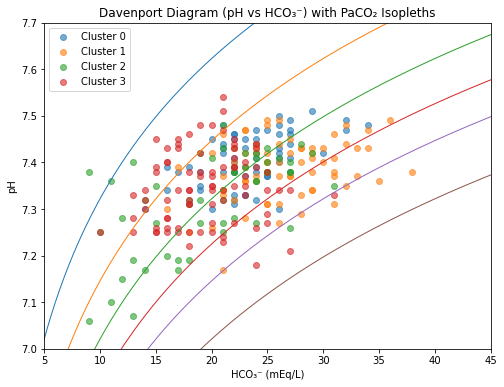

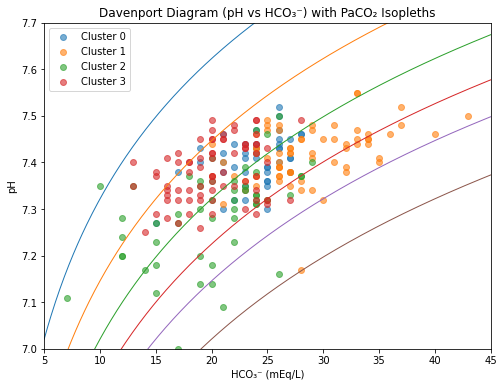

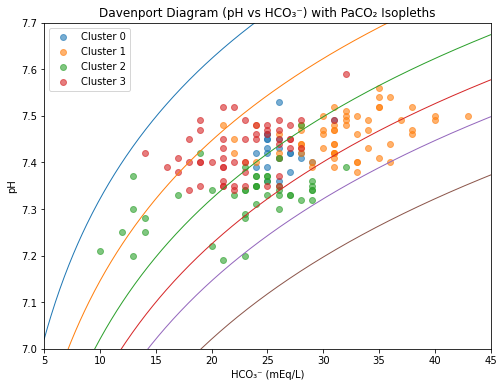

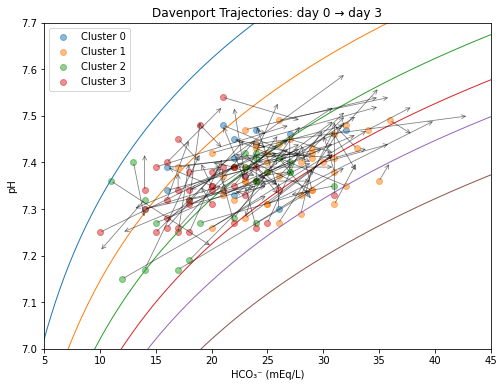

        phabg_0                     paco2abg_0                       bicarb_0  \
          count      mean       std      count       mean        std    count   
cluster                                                                         
0            63  7.408730  0.055343         63  37.523810   5.444314       66   
1            75  7.386800  0.063078         75  42.826667   7.651838       79   
2            52  7.319038  0.102273         52  36.980769  10.131470       52   
3            83  7.344458  0.077605         83  35.879518   8.635431       85   

                             pao2abg_0                        fio2abg_0  \
              mean       std     count        mean        std     count   
cluster                                                                   
0        23.500000  3.709655        63   94.158730  41.648764        63   
1        26.696203  5.137480        75  100.213333  49.180663        75   
2        19.865385  5.715575        52   88.307692  40.02

In [24]:
# ============================
# Minimal PyTorch Autoencoder + Clustering + Davenport Plotting
# Assumes you already have:
#   df  (alta_bypt_EARLYMODEL.csv loaded)
#   X   (NN feature matrix, shape (282, 48))
# ============================

import numpy as np
import pandas as pd

# ----------------------------
# 1) Preprocess: impute + scale
# ----------------------------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_df = X.copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X_df)
X_scaled = scaler.fit_transform(X_imp).astype(np.float32)

print("X_scaled:", X_scaled.shape, X_scaled.dtype)


# ----------------------------
# 2) Minimal PyTorch Autoencoder
# ----------------------------
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
ds = TensorDataset(X_tensor)
dl = DataLoader(ds, batch_size=64, shuffle=True)

class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        xhat = self.decoder(z)
        return xhat

def train_autoencoder(X_tensor, latent_dim=5, lr=1e-3, epochs=300, weight_decay=1e-5):
    model = AutoEncoder(input_dim=X_tensor.shape[1], latent_dim=latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    model.train()
    for ep in range(1, epochs + 1):
        losses = []
        for (xb,) in dl:
            xb = xb.to(device)
            xhat = model(xb)
            loss = loss_fn(xhat, xb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
        if ep in [1, 5, 10, 25, 50, 100, 200, epochs]:
            print(f"Epoch {ep:>3}/{epochs} | loss={np.mean(losses):.5f}")

    return model

ae = train_autoencoder(X_tensor, latent_dim=5, epochs=250)

# Get latent embeddings
ae.eval()
with torch.no_grad():
    Z = ae.encoder(X_tensor.to(device)).cpu().numpy()

print("Latent Z:", Z.shape)


# ----------------------------
# 3) Cluster latent space
# ----------------------------
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

K = 4  # try 3–6
kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto")
cluster_km = kmeans.fit_predict(Z)

gmm = GaussianMixture(n_components=K, random_state=42)
cluster_gmm = gmm.fit_predict(Z)

# Choose one:
df["cluster"] = cluster_gmm  # or cluster_km

print(df["cluster"].value_counts().sort_index())


# ----------------------------
# 4) Davenport plotting utilities
#    Plot pH vs HCO3 with PaCO2 isopleths via Henderson–Hasselbalch:
#      pH = 6.1 + log10(HCO3 / (0.03 * PaCO2))
# ----------------------------
import matplotlib.pyplot as plt

def davenport_isopleths(ax, pco2_values=(20, 30, 40, 50, 60, 80), hco3_range=(5, 45)):
    hco3 = np.linspace(hco3_range[0], hco3_range[1], 400)
    for pco2 in pco2_values:
        ph = 6.1 + np.log10(hco3 / (0.03 * pco2))
        ax.plot(hco3, ph, linewidth=1)

    ax.set_xlabel("HCO₃⁻ (mEq/L)")
    ax.set_ylabel("pH")
    ax.set_xlim(hco3_range)
    ax.set_ylim(7.0, 7.7)
    ax.set_title("Davenport Diagram (pH vs HCO₃⁻) with PaCO₂ Isopleths")

def plot_davenport_points(df, t=0, cluster_col="cluster", alpha=0.6):
    # Uses serum bicarb_t + ABG pH_t + ABG PaCO2_t (for label/filters if needed)
    bcol = f"bicarb_{t}"
    pcol = f"phabg_{t}"

    plot_df = df.dropna(subset=[bcol, pcol, cluster_col]).copy()

    fig, ax = plt.subplots(figsize=(8, 6))
    davenport_isopleths(ax)

    # scatter by cluster (no explicit colors set)
    for k in sorted(plot_df[cluster_col].unique()):
        sub = plot_df[plot_df[cluster_col] == k]
        ax.scatter(sub[bcol], sub[pcol], alpha=alpha, label=f"Cluster {k}")

    ax.legend()
    plt.show()

def plot_davenport_trajectories(df, t_start=0, t_end=3, cluster_col="cluster", n_max=120):
    # Draw arrows from t_start to t_end for a subset (to avoid clutter)
    b0, p0 = f"bicarb_{t_start}", f"phabg_{t_start}"
    b1, p1 = f"bicarb_{t_end}",   f"phabg_{t_end}"

    plot_df = df.dropna(subset=[b0, p0, b1, p1, cluster_col]).copy()
    if len(plot_df) > n_max:
        plot_df = plot_df.sample(n=n_max, random_state=42)

    fig, ax = plt.subplots(figsize=(8, 6))
    davenport_isopleths(ax)

    for k in sorted(plot_df[cluster_col].unique()):
        sub = plot_df[plot_df[cluster_col] == k]
        # plot start points
        ax.scatter(sub[b0], sub[p0], alpha=0.5, label=f"Cluster {k}")
        # arrows to end
        for _, r in sub.iterrows():
            ax.annotate(
                "",
                xy=(r[b1], r[p1]),
                xytext=(r[b0], r[p0]),
                arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.5),
            )

    ax.set_title(f"Davenport Trajectories: day {t_start} → day {t_end}")
    ax.legend()
    plt.show()


# ----------------------------
# 5) Make the plots
# ----------------------------
plot_davenport_points(df, t=0, cluster_col="cluster")
plot_davenport_points(df, t=1, cluster_col="cluster")
plot_davenport_points(df, t=3, cluster_col="cluster")

plot_davenport_trajectories(df, t_start=0, t_end=3, cluster_col="cluster", n_max=120)


# ----------------------------
# 6) Optional: quick cluster summaries (acid-base + oxygenation)
# ----------------------------
def summarize_by_cluster(df, t=0):
    cols = [f"phabg_{t}", f"paco2abg_{t}", f"bicarb_{t}", f"pao2abg_{t}", f"fio2abg_{t}"]
    cols = [c for c in cols if c in df.columns]
    return df.groupby("cluster")[cols].agg(["count", "mean", "std"])

print(summarize_by_cluster(df, t=0))


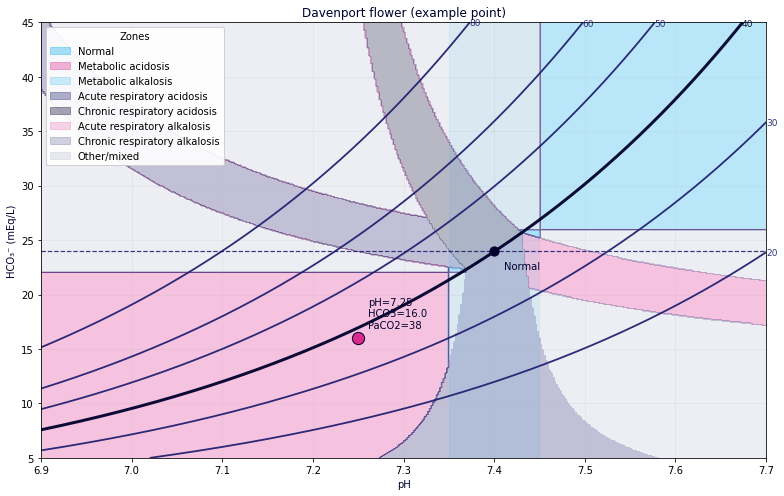

(<Figure size 792x504 with 1 Axes>,
 <Axes: title={'center': 'Davenport flower (example point)'}, xlabel='pH', ylabel='HCO₃⁻ (mEq/L)'>)

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# ----------------------------
# Henderson–Hasselbalch helpers
# ----------------------------
def paco2_from_ph_hco3(ph, hco3, pK=6.1, alpha=0.03):
    return hco3 / (alpha * (10 ** (ph - pK)))

def hco3_from_ph_paco2(ph, paco2, pK=6.1, alpha=0.03):
    return alpha * paco2 * (10 ** (ph - pK))

# ----------------------------
# Respiratory compensation "bands" (classic teaching approximations)
# Baseline normal: PaCO2=40, HCO3=24
# ----------------------------
def hco3_expected_resp(paco2, kind):
    delta = paco2 - 40.0
    if kind == "acute_ra":          # acute resp acidosis: +1 per +10 PaCO2
        return 24.0 + 1.0 * (delta / 10.0)
    if kind == "chronic_ra":        # chronic resp acidosis: +3.5 per +10
        return 24.0 + 3.5 * (delta / 10.0)
    if kind == "acute_ralk":        # acute resp alkalosis: -2 per -10 (delta negative)
        return 24.0 + 2.0 * (delta / 10.0)
    if kind == "chronic_ralk":      # chronic resp alkalosis: -6 per -10 (midpoint)
        return 24.0 + 6.0 * (delta / 10.0)
    raise ValueError("Unknown kind")

# ----------------------------
# Flower background (vectorized) + optional overlay of points / clusters
# Zones (codes):
# 0 Normal
# 1 Metabolic acidosis
# 2 Metabolic alkalosis
# 3 Acute respiratory acidosis
# 4 Chronic respiratory acidosis
# 5 Acute respiratory alkalosis
# 6 Chronic respiratory alkalosis
# 7 Other/mixed
# ----------------------------
MS_CERULEAN = "#06ABEB"
MS_PINK     = "#DC298D"
MS_BLUE     = "#212070"
MS_DARK     = "#00002D"
MS_MIXED    = "#BFC3D6"

def plot_davenport_flower(
    ph_range=(6.9, 7.7),
    hco3_range=(5, 45),
    paco2_lines=(20, 30, 40, 50, 60, 80),
    grid_n=420,
    tol_hco3=1.7,
    normal_ph=(7.35, 7.45),
    normal_hco3=(22, 26),
    normal_paco2=(35, 45),
    title="Davenport diagram (flower)",
    point=None,             # optional (x=pH, y=HCO3) or (pH, PaCO2) depending on mode
    point_mode="ph_hco3",   # "ph_hco3" or "ph_paco2"
    show=True
):
    # Grid in displayed coordinates: x=pH, y=HCO3
    ph = np.linspace(ph_range[0], ph_range[1], grid_n)
    hco3 = np.linspace(hco3_range[0], hco3_range[1], grid_n)
    PH, HCO3 = np.meshgrid(ph, hco3)

    # Implied PaCO2 at each (pH, HCO3)
    PACO2 = paco2_from_ph_hco3(PH, HCO3)

    # Expected HCO3 bands for the implied PaCO2
    H_acute_ra   = hco3_expected_resp(PACO2, "acute_ra")
    H_chron_ra   = hco3_expected_resp(PACO2, "chronic_ra")
    H_acute_ralk = hco3_expected_resp(PACO2, "acute_ralk")
    H_chron_ralk = hco3_expected_resp(PACO2, "chronic_ralk")

    # Start everything as "Other/mixed"
    Z = np.full(PH.shape, 7, dtype=int)

    # Normal box (all three within ranges)
    normal_mask = (
        (normal_ph[0] <= PH) & (PH <= normal_ph[1]) &
        (normal_hco3[0] <= HCO3) & (HCO3 <= normal_hco3[1]) &
        (normal_paco2[0] <= PACO2) & (PACO2 <= normal_paco2[1])
    )
    Z[normal_mask] = 0

    # Respiratory acidosis petals (PaCO2 > 40)
    ra = (PACO2 > 40)
    acute_ra_mask  = ra & (np.abs(HCO3 - H_acute_ra) <= tol_hco3)
    chron_ra_mask  = ra & (np.abs(HCO3 - H_chron_ra) <= tol_hco3)

    # Respiratory alkalosis petals (PaCO2 < 40)
    ralk = (PACO2 < 40)
    acute_ralk_mask = ralk & (np.abs(HCO3 - H_acute_ralk) <= tol_hco3)
    chron_ralk_mask = ralk & (np.abs(HCO3 - H_chron_ralk) <= tol_hco3)

    # Assign respiratory zones (do these BEFORE metabolic so petals win)
    Z[acute_ra_mask]   = 3
    Z[chron_ra_mask]   = 4
    Z[acute_ralk_mask] = 5
    Z[chron_ralk_mask] = 6

    # Metabolic zones (simple, but clinically intuitive: need BOTH pH + HCO3 direction)
    # Metabolic acidosis: low HCO3 + acidemia
    met_acid = (HCO3 < 22) & (PH < 7.35) & (~normal_mask) & (Z == 7)
    # Metabolic alkalosis: high HCO3 + alkalemia
    met_alk  = (HCO3 > 26) & (PH > 7.45) & (~normal_mask) & (Z == 7)
    Z[met_acid] = 1
    Z[met_alk]  = 2

    # Color map (Sinai theme)
    zone_colors = [
        MS_CERULEAN,  # 0 Normal
        MS_PINK,      # 1 Met acidosis
        MS_CERULEAN,  # 2 Met alkalosis (same hue; alpha differentiates visually)
        MS_BLUE,      # 3 Acute resp acidosis
        MS_DARK,      # 4 Chronic resp acidosis
        MS_PINK,      # 5 Acute resp alkalosis
        MS_BLUE,      # 6 Chronic resp alkalosis
        MS_MIXED      # 7 Other/mixed
    ]
    cmap = ListedColormap(zone_colors)
    bounds = np.arange(-0.5, 8.5, 1.0)
    norm = BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(11, 7))

    # Background zones
    ax.contourf(PH, HCO3, Z, levels=bounds, cmap=cmap, norm=norm, alpha=0.28)

    # Reference: normal pH band + HCO3=24
    ax.axvspan(7.35, 7.45, color=MS_CERULEAN, alpha=0.08)
    ax.axhline(24, linestyle="--", linewidth=1.2, color=MS_BLUE, alpha=0.9)

    # PaCO2 isopleths on top (H-H)
    ph_line = np.linspace(ph_range[0], ph_range[1], 900)
    for pco2 in paco2_lines:
        hco3_line = hco3_from_ph_paco2(ph_line, pco2)
        mask = (hco3_line >= hco3_range[0]) & (hco3_line <= hco3_range[1])
        lw = 3.0 if pco2 == 40 else 1.8
        col = MS_DARK if pco2 == 40 else MS_BLUE
        ax.plot(ph_line[mask], hco3_line[mask], linewidth=lw, color=col, alpha=0.95)

        # label isopleths lightly at right edge
        if mask.any():
            idx = np.where(mask)[0][-1]
            ax.text(ph_line[idx], hco3_line[idx], f"{pco2}", fontsize=9,
                    color=col, ha="left", va="center", alpha=0.9)

    # Normal point
    ax.scatter([7.40], [24], s=85, color=MS_DARK, zorder=6)
    ax.annotate("Normal", (7.40, 24), textcoords="offset points", xytext=(10, -18), color=MS_DARK)

    # Optional single point overlay
    if point is not None:
        if point_mode == "ph_hco3":
            ph_pt, hco3_pt = point
            paco2_pt = float(paco2_from_ph_hco3(ph_pt, hco3_pt))
        elif point_mode == "ph_paco2":
            ph_pt, paco2_pt = point
            hco3_pt = float(hco3_from_ph_paco2(ph_pt, paco2_pt))
        else:
            raise ValueError("point_mode must be 'ph_hco3' or 'ph_paco2'")

        ax.scatter([ph_pt], [hco3_pt], s=150, color=MS_PINK, edgecolor=MS_DARK, linewidth=1.0, zorder=7)
        ax.annotate(f"pH={ph_pt:.2f}\nHCO3={hco3_pt:.1f}\nPaCO2={paco2_pt:.0f}",
                    (ph_pt, hco3_pt), textcoords="offset points", xytext=(10, 10), color=MS_DARK)

    # Legends (zones)
    zone_labels = [
        ("Normal", 0, 0.35),
        ("Metabolic acidosis", 1, 0.35),
        ("Metabolic alkalosis", 2, 0.20),
        ("Acute respiratory acidosis", 3, 0.35),
        ("Chronic respiratory acidosis", 4, 0.35),
        ("Acute respiratory alkalosis", 5, 0.20),
        ("Chronic respiratory alkalosis", 6, 0.20),
        ("Other/mixed", 7, 0.35),
    ]
    patches = [mpatches.Patch(color=zone_colors[z], label=name, alpha=a) for (name, z, a) in zone_labels]
    ax.legend(handles=patches, loc="upper left", title="Zones", framealpha=0.92)

    ax.set_xlim(*ph_range)
    ax.set_ylim(*hco3_range)
    ax.set_xlabel("pH", color=MS_DARK)
    ax.set_ylabel("HCO₃⁻ (mEq/L)", color=MS_DARK)
    ax.set_title(title, color=MS_DARK)
    ax.grid(alpha=0.18)

    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax

# ----------------------------
# Overlay YOUR data points colored by cluster on the flower
# (x=pH, y=HCO3)
# ----------------------------
def plot_davenport_flower_with_clusters(df, t=0, cluster_col="cluster",
                                       ph_range=(6.9, 7.7), hco3_range=(5, 45),
                                       paco2_lines=(20, 30, 40, 50, 60, 80),
                                       alpha_pts=0.65, s=28):
    pcol = f"phabg_{t}"
    hcol = f"bicarb_{t}"
    use = df.dropna(subset=[pcol, hcol, cluster_col]).copy()

    fig, ax = plot_davenport_flower(
        ph_range=ph_range,
        hco3_range=hco3_range,
        paco2_lines=paco2_lines,
        title=f"Davenport flower + clusters (Day {t})",
        show=False
    )

    # Use matplotlib default colors for clusters (keeps it simple + readable)
    for k in sorted(use[cluster_col].unique()):
        sub = use[use[cluster_col] == k]
        ax.scatter(sub[pcol], sub[hcol], alpha=alpha_pts, s=s, label=f"Cluster {k}")

    ax.legend(loc="lower right", title="Clusters", framealpha=0.92)
    plt.show()

def plot_davenport_flower_trajectories(df, t0=0, t1=3, cluster_col="cluster",
                                       n_max=140, ph_range=(6.9, 7.7), hco3_range=(5, 45),
                                       paco2_lines=(20, 30, 40, 50, 60, 80)):
    p0, h0 = f"phabg_{t0}", f"bicarb_{t0}"
    p1, h1 = f"phabg_{t1}", f"bicarb_{t1}"

    use = df.dropna(subset=[p0, h0, p1, h1, cluster_col]).copy()
    if len(use) > n_max:
        use = use.sample(n=n_max, random_state=42)

    fig, ax = plot_davenport_flower(
        ph_range=ph_range,
        hco3_range=hco3_range,
        paco2_lines=paco2_lines,
        title=f"Davenport flower trajectories (Day {t0} → Day {t1})",
        show=False
    )

    for k in sorted(use[cluster_col].unique()):
        sub = use[use[cluster_col] == k]
        ax.scatter(sub[p0], sub[h0], alpha=0.5, s=26, label=f"Cluster {k}")
        for _, r in sub.iterrows():
            ax.annotate(
                "",
                xy=(r[p1], r[h1]),
                xytext=(r[p0], r[h0]),
                arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.5),
            )

    ax.legend(loc="lower right", title="Clusters", framealpha=0.92)
    plt.show()

# ----------------------------
# Examples
# ----------------------------
# Background “flower” with a single illustrative point:
plot_davenport_flower(point=(7.25, 16), point_mode="ph_hco3", title="Davenport flower (example point)")

# With your clustering results (after df['cluster'] exists):
# plot_davenport_flower_with_clusters(df, t=0, cluster_col="cluster")
# plot_davenport_flower_with_clusters(df, t=3, cluster_col="cluster")
# plot_davenport_flower_trajectories(df, t0=0, t1=3, cluster_col="cluster", n_max=140)


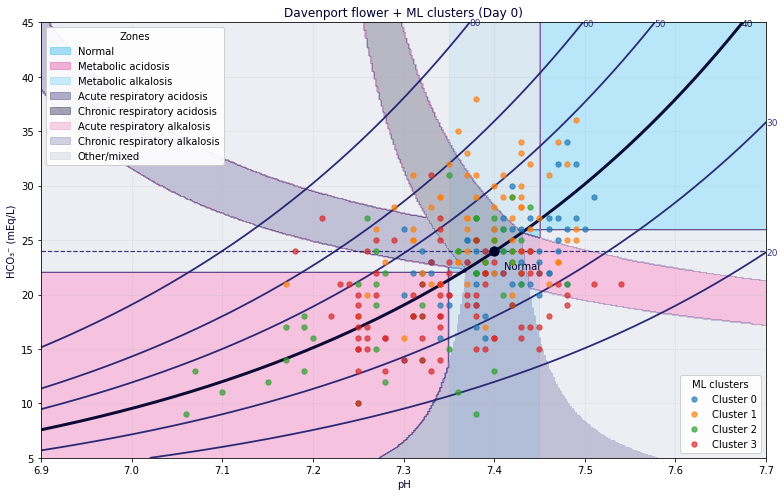

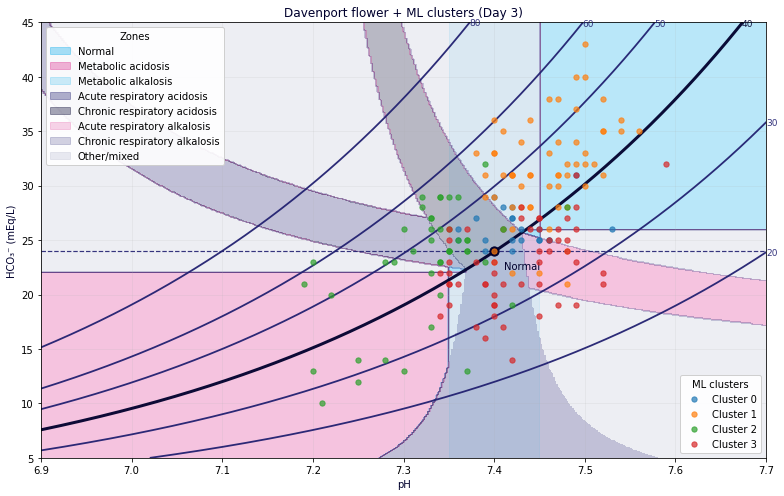

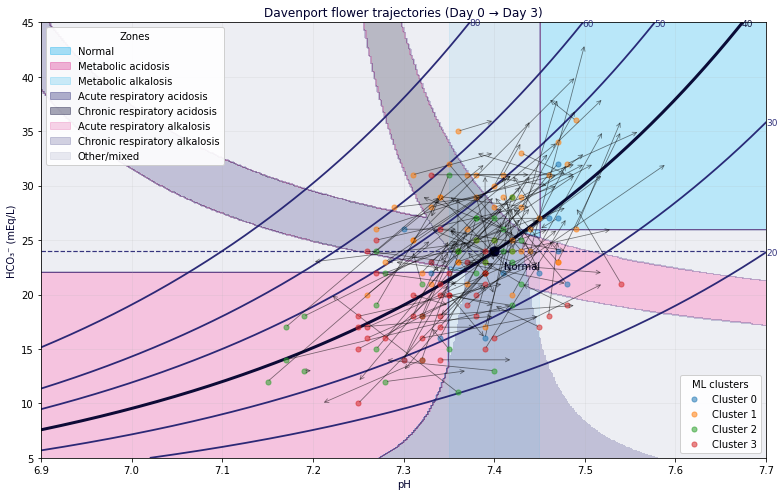

In [26]:
# ============================================================
# Davenport "flower" background + ML cluster points/trajectories
# (Use after you have df["cluster"] from your autoencoder+GMM)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# ----------------------------
# Henderson–Hasselbalch helpers
# ----------------------------
def paco2_from_ph_hco3(ph, hco3, pK=6.1, alpha=0.03):
    return hco3 / (alpha * (10 ** (ph - pK)))

def hco3_from_ph_paco2(ph, paco2, pK=6.1, alpha=0.03):
    return alpha * paco2 * (10 ** (ph - pK))

# ----------------------------
# Respiratory compensation lines (teaching approximations)
# Baseline normal: PaCO2=40, HCO3=24
# ----------------------------
def hco3_expected_resp(paco2, kind):
    delta = paco2 - 40.0
    if kind == "acute_ra":          # acute resp acidosis
        return 24.0 + 1.0 * (delta / 10.0)
    if kind == "chronic_ra":        # chronic resp acidosis
        return 24.0 + 3.5 * (delta / 10.0)
    if kind == "acute_ralk":        # acute resp alkalosis
        return 24.0 + 2.0 * (delta / 10.0)   # delta negative -> decreases
    if kind == "chronic_ralk":      # chronic resp alkalosis midpoint (≈6)
        return 24.0 + 6.0 * (delta / 10.0)   # delta negative -> larger decrease
    raise ValueError("Unknown kind")

# ----------------------------
# Mount Sinai palette
# ----------------------------
MS_CERULEAN = "#06ABEB"
MS_PINK     = "#DC298D"
MS_BLUE     = "#212070"
MS_DARK     = "#00002D"
MS_MIXED    = "#BFC3D6"

# ----------------------------
# Build flower background (vectorized zone classification)
# x-axis = pH ; y-axis = HCO3
# ----------------------------
def make_flower_background(
    ph_range=(6.9, 7.7),
    hco3_range=(5, 45),
    grid_n=420,
    tol_hco3=1.7,
    normal_ph=(7.35, 7.45),
    normal_hco3=(22, 26),
    normal_paco2=(35, 45)
):
    ph = np.linspace(ph_range[0], ph_range[1], grid_n)
    hco3 = np.linspace(hco3_range[0], hco3_range[1], grid_n)
    PH, HCO3 = np.meshgrid(ph, hco3)

    PACO2 = paco2_from_ph_hco3(PH, HCO3)

    H_acute_ra   = hco3_expected_resp(PACO2, "acute_ra")
    H_chron_ra   = hco3_expected_resp(PACO2, "chronic_ra")
    H_acute_ralk = hco3_expected_resp(PACO2, "acute_ralk")
    H_chron_ralk = hco3_expected_resp(PACO2, "chronic_ralk")

    Z = np.full(PH.shape, 7, dtype=int)

    normal_mask = (
        (normal_ph[0] <= PH) & (PH <= normal_ph[1]) &
        (normal_hco3[0] <= HCO3) & (HCO3 <= normal_hco3[1]) &
        (normal_paco2[0] <= PACO2) & (PACO2 <= normal_paco2[1])
    )
    Z[normal_mask] = 0

    ra = (PACO2 > 40)
    acute_ra_mask = ra & (np.abs(HCO3 - H_acute_ra) <= tol_hco3)
    chron_ra_mask = ra & (np.abs(HCO3 - H_chron_ra) <= tol_hco3)

    ralk = (PACO2 < 40)
    acute_ralk_mask = ralk & (np.abs(HCO3 - H_acute_ralk) <= tol_hco3)
    chron_ralk_mask = ralk & (np.abs(HCO3 - H_chron_ralk) <= tol_hco3)

    Z[acute_ra_mask]   = 3
    Z[chron_ra_mask]   = 4
    Z[acute_ralk_mask] = 5
    Z[chron_ralk_mask] = 6

    # metabolic zones (require pH direction too)
    met_acid = (HCO3 < 22) & (PH < 7.35) & (~normal_mask) & (Z == 7)
    met_alk  = (HCO3 > 26) & (PH > 7.45) & (~normal_mask) & (Z == 7)
    Z[met_acid] = 1
    Z[met_alk]  = 2

    return PH, HCO3, Z

# ----------------------------
# Draw flower + PaCO2 isopleths
# ----------------------------
def draw_flower(ax, PH, HCO3, Z,
                ph_range=(6.9, 7.7),
                hco3_range=(5, 45),
                paco2_lines=(20, 30, 40, 50, 60, 80),
                title="Davenport flower",
                alpha_bg=0.28):
    zone_colors = [
        MS_CERULEAN,  # 0 Normal
        MS_PINK,      # 1 Met acidosis
        MS_CERULEAN,  # 2 Met alkalosis
        MS_BLUE,      # 3 Acute resp acidosis
        MS_DARK,      # 4 Chronic resp acidosis
        MS_PINK,      # 5 Acute resp alkalosis
        MS_BLUE,      # 6 Chronic resp alkalosis
        MS_MIXED      # 7 Other/mixed
    ]
    cmap = ListedColormap(zone_colors)
    bounds = np.arange(-0.5, 8.5, 1.0)
    norm = BoundaryNorm(bounds, cmap.N)

    ax.contourf(PH, HCO3, Z, levels=bounds, cmap=cmap, norm=norm, alpha=alpha_bg)

    # reference normal band + HCO3=24
    ax.axvspan(7.35, 7.45, color=MS_CERULEAN, alpha=0.08)
    ax.axhline(24, linestyle="--", linewidth=1.2, color=MS_BLUE, alpha=0.9)

    # isopleths
    ph_line = np.linspace(ph_range[0], ph_range[1], 900)
    for pco2 in paco2_lines:
        hco3_line = hco3_from_ph_paco2(ph_line, pco2)
        mask = (hco3_line >= hco3_range[0]) & (hco3_line <= hco3_range[1])
        lw = 3.0 if pco2 == 40 else 1.8
        col = MS_DARK if pco2 == 40 else MS_BLUE
        ax.plot(ph_line[mask], hco3_line[mask], linewidth=lw, color=col, alpha=0.95)

        if mask.any():
            idx = np.where(mask)[0][-1]
            ax.text(ph_line[idx], hco3_line[idx], f"{pco2}", fontsize=9,
                    color=col, ha="left", va="center", alpha=0.9)

    # normal point
    ax.scatter([7.40], [24], s=85, color=MS_DARK, zorder=5)
    ax.annotate("Normal", (7.40, 24), textcoords="offset points", xytext=(10, -18), color=MS_DARK)

    # zone legend
    zone_labels = [
        ("Normal", 0, 0.35),
        ("Metabolic acidosis", 1, 0.35),
        ("Metabolic alkalosis", 2, 0.20),
        ("Acute respiratory acidosis", 3, 0.35),
        ("Chronic respiratory acidosis", 4, 0.35),
        ("Acute respiratory alkalosis", 5, 0.20),
        ("Chronic respiratory alkalosis", 6, 0.20),
        ("Other/mixed", 7, 0.35),
    ]
    patches = [mpatches.Patch(color=zone_colors[z], label=name, alpha=a) for (name, z, a) in zone_labels]
    leg1 = ax.legend(handles=patches, loc="upper left", title="Zones", framealpha=0.92)
    ax.add_artist(leg1)

    ax.set_xlim(*ph_range)
    ax.set_ylim(*hco3_range)
    ax.set_xlabel("pH", color=MS_DARK)
    ax.set_ylabel("HCO₃⁻ (mEq/L)", color=MS_DARK)
    ax.set_title(title, color=MS_DARK)
    ax.grid(alpha=0.18)

# ----------------------------
# Plot ML points (colored by cluster) on top of the flower
# ----------------------------
def plot_flower_with_ml_points(df, t=0, cluster_col="cluster",
                               ph_range=(6.9, 7.7), hco3_range=(5, 45),
                               paco2_lines=(20, 30, 40, 50, 60, 80),
                               grid_n=420, tol_hco3=1.7,
                               alpha_pts=0.70, s=28):
    pcol = f"phabg_{t}"
    hcol = f"bicarb_{t}"

    use = df.dropna(subset=[pcol, hcol, cluster_col]).copy()

    PH, HCO3, Z = make_flower_background(
        ph_range=ph_range, hco3_range=hco3_range,
        grid_n=grid_n, tol_hco3=tol_hco3
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    draw_flower(ax, PH, HCO3, Z, ph_range=ph_range, hco3_range=hco3_range,
                paco2_lines=paco2_lines,
                title=f"Davenport flower + ML clusters (Day {t})")

    # ML points (default matplotlib colors)
    for k in sorted(use[cluster_col].unique()):
        sub = use[use[cluster_col] == k]
        ax.scatter(sub[pcol], sub[hcol], alpha=alpha_pts, s=s, label=f"Cluster {k}", zorder=6)

    ax.legend(loc="lower right", title="ML clusters", framealpha=0.92)
    plt.tight_layout()
    plt.show()

# ----------------------------
# Plot trajectories day t0 -> t1 on the flower
# ----------------------------
def plot_flower_with_ml_trajectories(df, t0=0, t1=3, cluster_col="cluster",
                                     ph_range=(6.9, 7.7), hco3_range=(5, 45),
                                     paco2_lines=(20, 30, 40, 50, 60, 80),
                                     grid_n=420, tol_hco3=1.7,
                                     n_max=140):
    p0, h0 = f"phabg_{t0}", f"bicarb_{t0}"
    p1, h1 = f"phabg_{t1}", f"bicarb_{t1}"
    use = df.dropna(subset=[p0, h0, p1, h1, cluster_col]).copy()

    if len(use) > n_max:
        use = use.sample(n=n_max, random_state=42)

    PH, HCO3, Z = make_flower_background(
        ph_range=ph_range, hco3_range=hco3_range,
        grid_n=grid_n, tol_hco3=tol_hco3
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    draw_flower(ax, PH, HCO3, Z, ph_range=ph_range, hco3_range=hco3_range,
                paco2_lines=paco2_lines,
                title=f"Davenport flower trajectories (Day {t0} → Day {t1})")

    for k in sorted(use[cluster_col].unique()):
        sub = use[use[cluster_col] == k]
        ax.scatter(sub[p0], sub[h0], alpha=0.55, s=26, label=f"Cluster {k}", zorder=6)
        for _, r in sub.iterrows():
            ax.annotate(
                "",
                xy=(r[p1], r[h1]),
                xytext=(r[p0], r[h0]),
                arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.5),
                zorder=6
            )

    ax.legend(loc="lower right", title="ML clusters", framealpha=0.92)
    plt.tight_layout()
    plt.show()

# ============================
# USAGE (after df["cluster"] exists)
# ============================
plot_flower_with_ml_points(df, t=0, cluster_col="cluster")
plot_flower_with_ml_points(df, t=3, cluster_col="cluster")
plot_flower_with_ml_trajectories(df, t0=0, t1=3, cluster_col="cluster", n_max=140)


In [37]:
def acid_base_category(row, t=0):
    ph = row[f"phabg_{t}"]
    paco2 = row[f"paco2abg_{t}"]
    hco3 = row[f"bicarb_{t}"]

    if pd.isna(ph) or pd.isna(paco2) or pd.isna(hco3):
        return np.nan

    if ph < 7.35 and paco2 > 45:
        return "Resp Acidosis"
    if ph < 7.35 and hco3 < 22:
        return "Met Acidosis"
    if ph > 7.45 and paco2 < 35:
        return "Resp Alkalosis"
    if ph > 7.45 and hco3 > 26:
        return "Met Alkalosis"
    return "Near Normal"

df["acid_base_class"] = df.apply(acid_base_category, axis=1)

pd.crosstab(df["cluster"], df["acid_base_class"], normalize="index")


from scipy.stats import chi2_contingency
import numpy as np

ct = pd.crosstab(df["cluster"], df["acid_base_class"])
chi2, p, _, _ = chi2_contingency(ct)

n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

chi2, p, cramers_v



(59.957410353479574, 2.2980608508742527e-08, 0.27056990085682076)

In [39]:
import numpy as np

PH_N = 7.40
PCO2_N = 40.0
HCO3_N = 24.0

df["davenport_dist_0"] = np.sqrt(
    ((df["phabg_0"] - PH_N) / 0.05) ** 2 +
    ((df["paco2abg_0"] - PCO2_N) / 10.0) ** 2 +
    ((df["bicarb_0"] - HCO3_N) / 4.0) ** 2
)

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols("davenport_dist_0 ~ C(cluster)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table



,sum_sq,df,F,PR(>F)
C(cluster),60.830073,3.0,13.944317,1.775314e-08
Residual,391.157901,269.0,NaN,NaN


In [42]:
def acid_base_category(row):
    ph = row["phabg_0"]
    paco2 = row["paco2abg_0"]
    hco3 = row["bicarb_0"]

    if pd.isna(ph) or pd.isna(paco2) or pd.isna(hco3):
        return np.nan

    if ph < 7.35 and paco2 > 45:
        return "Resp Acidosis"
    if ph < 7.35 and hco3 < 22:
        return "Met Acidosis"
    if ph > 7.45 and paco2 < 35:
        return "Resp Alkalosis"
    if ph > 7.45 and hco3 > 26:
        return "Met Alkalosis"
    return "Near Normal"

df["acid_base_class"] = df.apply(acid_base_category, axis=1)


In [44]:
from scipy.stats import chi2_contingency
import numpy as np

ct = pd.crosstab(df["cluster"], df["acid_base_class"])
chi2, p, _, _ = chi2_contingency(ct)

n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

chi2, p, cramers_v


(59.957410353479574, 2.2980608508742527e-08, 0.27056990085682076)

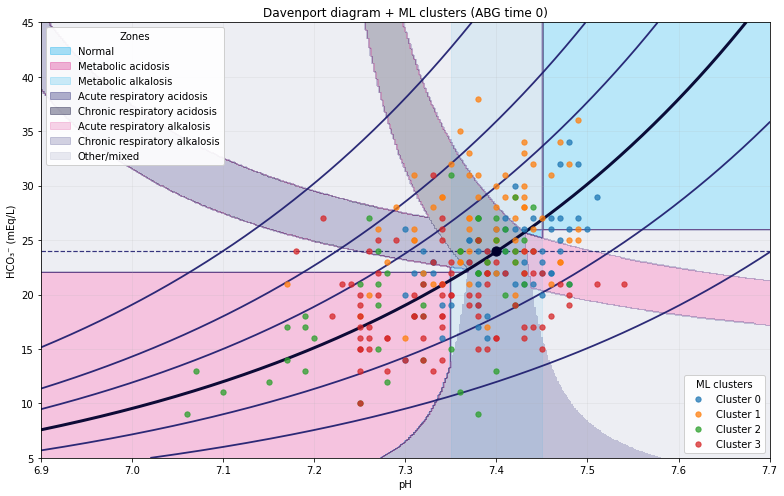

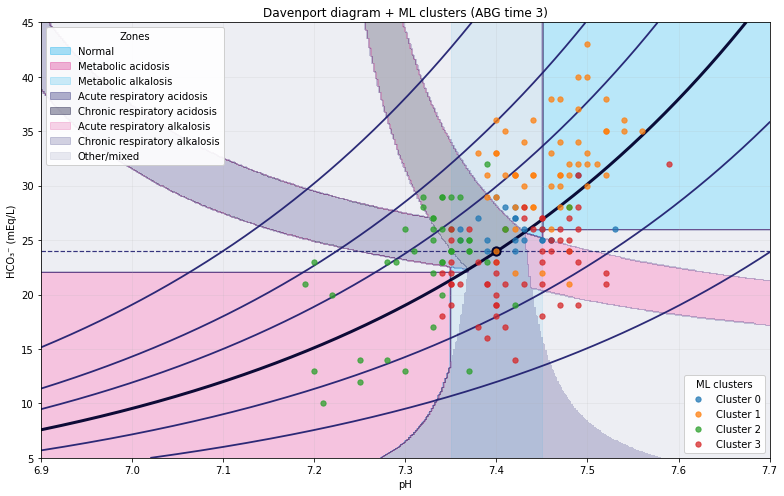

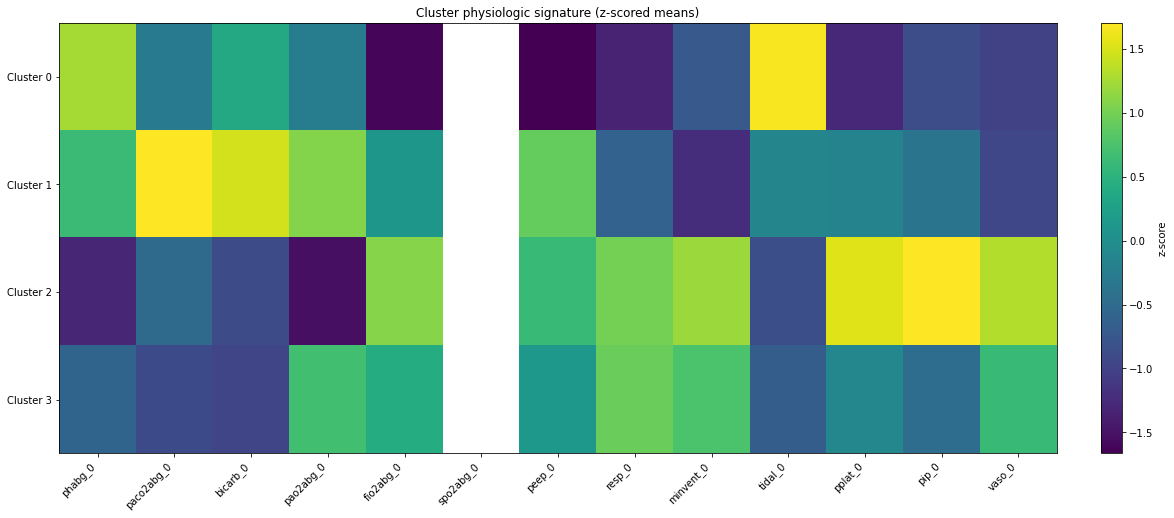

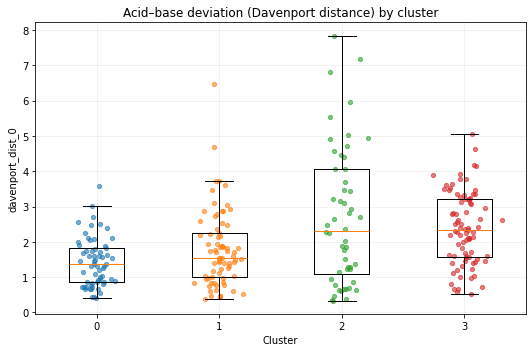

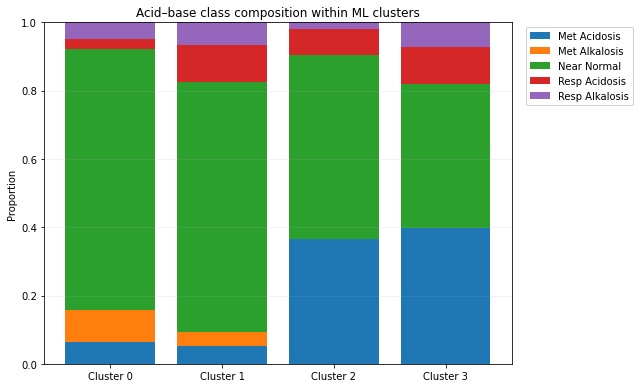

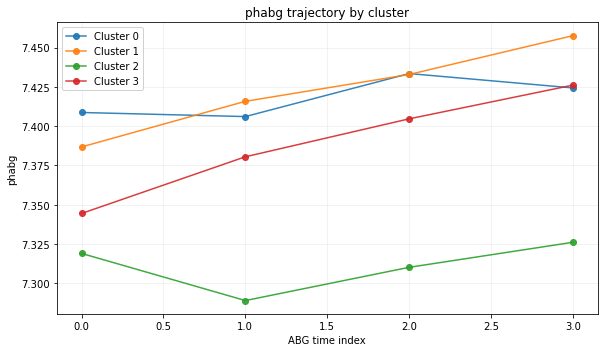

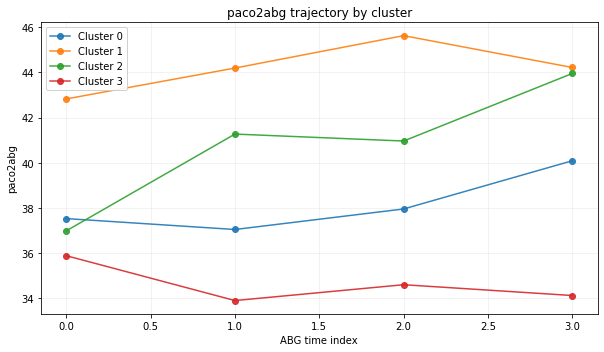

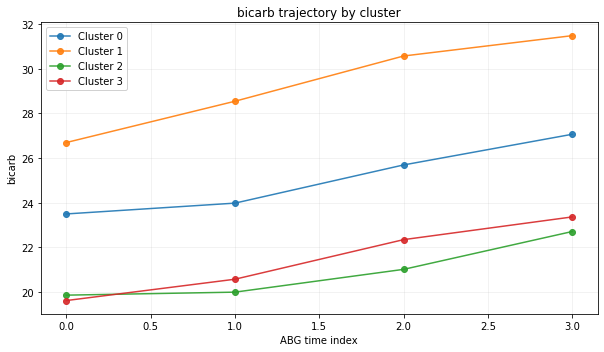

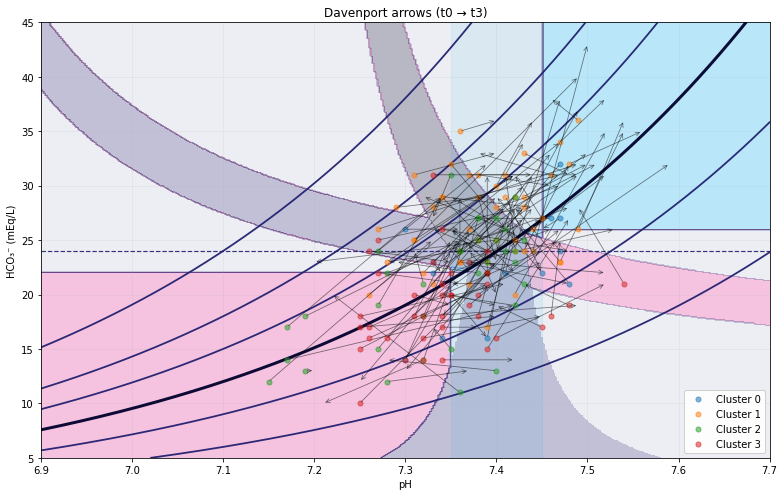

In [46]:

# ============================================================
# ARDS ML Visualization Pack (exact code)
# Assumes you already have:
#   df : pandas DataFrame (one row per patient)
#   df["cluster"] : int cluster labels
#   ABG columns: phabg_0..3, paco2abg_0..3, bicarb_0..3
# Optional but recommended:
#   Z : (n_patients, latent_dim) numpy array from your autoencoder (e.g., 282x5)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Helper: create acid_base_class + davenport_dist_0 if missing
# ----------------------------
def ensure_acid_base_class_and_distance(df):
    if "acid_base_class" not in df.columns:
        def acid_base_category(row):
            ph = row.get("phabg_0", np.nan)
            paco2 = row.get("paco2abg_0", np.nan)
            hco3 = row.get("bicarb_0", np.nan)
            if pd.isna(ph) or pd.isna(paco2) or pd.isna(hco3):
                return np.nan
            if ph < 7.35 and paco2 > 45:
                return "Resp Acidosis"
            if ph < 7.35 and hco3 < 22:
                return "Met Acidosis"
            if ph > 7.45 and paco2 < 35:
                return "Resp Alkalosis"
            if ph > 7.45 and hco3 > 26:
                return "Met Alkalosis"
            return "Near Normal"
        df["acid_base_class"] = df.apply(acid_base_category, axis=1)

    if "davenport_dist_0" not in df.columns:
        PH_N, PCO2_N, HCO3_N = 7.40, 40.0, 24.0
        # scaled Euclidean: easy to interpret + stable
        df["davenport_dist_0"] = np.sqrt(
            ((df["phabg_0"] - PH_N) / 0.05) ** 2 +
            ((df["paco2abg_0"] - PCO2_N) / 10.0) ** 2 +
            ((df["bicarb_0"] - HCO3_N) / 4.0) ** 2
        )
    return df

df = ensure_acid_base_class_and_distance(df)

# ----------------------------
# 1) Davenport flower background + ML cluster scatter
# ----------------------------
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

def paco2_from_ph_hco3(ph, hco3, pK=6.1, alpha=0.03):
    return hco3 / (alpha * (10 ** (ph - pK)))

def hco3_from_ph_paco2(ph, paco2, pK=6.1, alpha=0.03):
    return alpha * paco2 * (10 ** (ph - pK))

def hco3_expected_resp(paco2, kind):
    delta = paco2 - 40.0
    if kind == "acute_ra": return 24.0 + 1.0 * (delta / 10.0)
    if kind == "chronic_ra": return 24.0 + 3.5 * (delta / 10.0)
    if kind == "acute_ralk": return 24.0 + 2.0 * (delta / 10.0)
    if kind == "chronic_ralk": return 24.0 + 6.0 * (delta / 10.0)
    raise ValueError("Unknown kind")

# "Mount Sinai-ish" palette
MS_CERULEAN = "#06ABEB"
MS_PINK     = "#DC298D"
MS_BLUE     = "#212070"
MS_DARK     = "#00002D"
MS_MIXED    = "#BFC3D6"

def make_flower_background(ph_range=(6.9, 7.7), hco3_range=(5, 45), grid_n=420, tol_hco3=1.7):
    ph = np.linspace(ph_range[0], ph_range[1], grid_n)
    hco3 = np.linspace(hco3_range[0], hco3_range[1], grid_n)
    PH, HCO3 = np.meshgrid(ph, hco3)
    PACO2 = paco2_from_ph_hco3(PH, HCO3)

    H_acute_ra   = hco3_expected_resp(PACO2, "acute_ra")
    H_chron_ra   = hco3_expected_resp(PACO2, "chronic_ra")
    H_acute_ralk = hco3_expected_resp(PACO2, "acute_ralk")
    H_chron_ralk = hco3_expected_resp(PACO2, "chronic_ralk")

    Z = np.full(PH.shape, 7, dtype=int)

    normal_mask = (
        (7.35 <= PH) & (PH <= 7.45) &
        (22 <= HCO3) & (HCO3 <= 26) &
        (35 <= PACO2) & (PACO2 <= 45)
    )
    Z[normal_mask] = 0

    ra = (PACO2 > 40)
    Z[ra & (np.abs(HCO3 - H_acute_ra) <= tol_hco3)] = 3
    Z[ra & (np.abs(HCO3 - H_chron_ra) <= tol_hco3)] = 4

    ralk = (PACO2 < 40)
    Z[ralk & (np.abs(HCO3 - H_acute_ralk) <= tol_hco3)] = 5
    Z[ralk & (np.abs(HCO3 - H_chron_ralk) <= tol_hco3)] = 6

    # metabolic zones (require pH direction too)
    met_acid = (HCO3 < 22) & (PH < 7.35) & (Z == 7)
    met_alk  = (HCO3 > 26) & (PH > 7.45) & (Z == 7)
    Z[met_acid] = 1
    Z[met_alk]  = 2

    return PH, HCO3, Z

def plot_davenport_clusters(df, t=0, cluster_col="cluster",
                            ph_range=(6.9, 7.7), hco3_range=(5, 45),
                            paco2_lines=(20, 30, 40, 50, 60, 80),
                            grid_n=420, tol_hco3=1.7,
                            s=28, alpha_pts=0.75):

    pcol = f"phabg_{t}"
    hcol = f"bicarb_{t}"

    use = df.dropna(subset=[pcol, hcol, cluster_col]).copy()

    PH, HCO3, Z = make_flower_background(ph_range, hco3_range, grid_n, tol_hco3)

    zone_colors = [MS_CERULEAN, MS_PINK, MS_CERULEAN, MS_BLUE, MS_DARK, MS_PINK, MS_BLUE, MS_MIXED]
    cmap = ListedColormap(zone_colors)
    bounds = np.arange(-0.5, 8.5, 1.0)
    norm = BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.contourf(PH, HCO3, Z, levels=bounds, cmap=cmap, norm=norm, alpha=0.28)

    # reference
    ax.axvspan(7.35, 7.45, color=MS_CERULEAN, alpha=0.08)
    ax.axhline(24, linestyle="--", linewidth=1.2, color=MS_BLUE, alpha=0.9)

    # PaCO2 isopleths
    ph_line = np.linspace(ph_range[0], ph_range[1], 900)
    for pco2 in paco2_lines:
        h_line = hco3_from_ph_paco2(ph_line, pco2)
        mask = (h_line >= hco3_range[0]) & (h_line <= hco3_range[1])
        lw = 3.0 if pco2 == 40 else 1.8
        col = MS_DARK if pco2 == 40 else MS_BLUE
        ax.plot(ph_line[mask], h_line[mask], linewidth=lw, color=col, alpha=0.95)

    # normal point
    ax.scatter([7.40], [24], s=85, color=MS_DARK, zorder=5)

    # ML points (matplotlib default color cycle)
    for k in sorted(use[cluster_col].unique()):
        sub = use[use[cluster_col] == k]
        ax.scatter(sub[pcol], sub[hcol], s=s, alpha=alpha_pts, label=f"Cluster {k}", zorder=6)

    # Zone legend patches
    zone_labels = [
        ("Normal", 0, 0.35),
        ("Metabolic acidosis", 1, 0.35),
        ("Metabolic alkalosis", 2, 0.20),
        ("Acute respiratory acidosis", 3, 0.35),
        ("Chronic respiratory acidosis", 4, 0.35),
        ("Acute respiratory alkalosis", 5, 0.20),
        ("Chronic respiratory alkalosis", 6, 0.20),
        ("Other/mixed", 7, 0.35),
    ]
    patches = [mpatches.Patch(color=zone_colors[z], label=name, alpha=a) for (name, z, a) in zone_labels]
    leg1 = ax.legend(handles=patches, loc="upper left", title="Zones", framealpha=0.92)
    ax.add_artist(leg1)

    ax.legend(loc="lower right", title="ML clusters", framealpha=0.92)

    ax.set_xlim(*ph_range); ax.set_ylim(*hco3_range)
    ax.set_xlabel("pH"); ax.set_ylabel("HCO₃⁻ (mEq/L)")
    ax.set_title(f"Davenport diagram + ML clusters (ABG time {t})")
    ax.grid(alpha=0.18)
    plt.tight_layout()
    plt.show()

# RUN:
plot_davenport_clusters(df, t=0)
plot_davenport_clusters(df, t=3)

# ----------------------------
# 2) Latent space plot (PCA 2D), colored by cluster and/or acid_base_class
# Requires Z array from your autoencoder
# ----------------------------
def plot_latent_pca(Z, df, color_by="cluster", title="Latent space (PCA)"):
    from sklearn.decomposition import PCA

    Z = np.asarray(Z)
    good = np.isfinite(Z).all(axis=1)
    Zg = Z[good]
    meta = df.loc[good].copy()

    pca = PCA(n_components=2, random_state=42)
    Y = pca.fit_transform(Zg)

    fig, ax = plt.subplots(figsize=(7.5, 6))
    if color_by == "cluster":
        for k in sorted(meta["cluster"].dropna().unique()):
            m = (meta["cluster"] == k).values
            ax.scatter(Y[m,0], Y[m,1], s=30, alpha=0.8, label=f"Cluster {k}")
        ax.legend(framealpha=0.9)
    else:
        classes = meta[color_by].astype("category")
        for c in classes.cat.categories:
            m = (classes == c).values
            ax.scatter(Y[m,0], Y[m,1], s=30, alpha=0.8, label=str(c))
        ax.legend(framealpha=0.9, title=color_by)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# RUN (after you have Z):
# plot_latent_pca(Z, df, color_by="cluster", title="Latent space colored by ML cluster")
# plot_latent_pca(Z, df, color_by="acid_base_class", title="Latent space colored by acid–base class")

# ----------------------------
# 3) Cluster feature heatmap (means of key features, z-scored)
# ----------------------------
def plot_cluster_feature_heatmap(df, features, cluster_col="cluster", title="Cluster physiologic signature (z-scored means)"):
    # compute cluster means
    M = df.groupby(cluster_col)[features].mean()
    # z-score columns for comparability
    Zm = (M - M.mean(axis=0)) / (M.std(axis=0, ddof=0) + 1e-9)

    fig, ax = plt.subplots(figsize=(1.0*len(features) + 3.5, 1.2*len(Zm) + 2.5))
    im = ax.imshow(Zm.values, aspect="auto")
    ax.set_yticks(range(Zm.shape[0]))
    ax.set_yticklabels([f"Cluster {i}" for i in Zm.index])
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels(features, rotation=45, ha="right")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="z-score")
    plt.tight_layout()
    plt.show()

key_features = [
    "phabg_0", "paco2abg_0", "bicarb_0",
    "pao2abg_0", "fio2abg_0", "spo2abg_0",
]
# add vent features if present
for f in ["peep_0", "resp_0", "minvent_0", "tidal_0", "pplat_0", "pip_0", "map", "vaso_0"]:
    if f in df.columns and f not in key_features:
        key_features.append(f)

plot_cluster_feature_heatmap(df, key_features)

# ----------------------------
# 4) Davenport distance by cluster (boxplot + points)
# ----------------------------
def plot_distance_by_cluster(df, dist_col="davenport_dist_0", cluster_col="cluster",
                             title="Acid–base deviation (Davenport distance) by cluster"):
    use = df.dropna(subset=[dist_col, cluster_col]).copy()
    clusters = sorted(use[cluster_col].unique())
    data = [use.loc[use[cluster_col]==k, dist_col].values for k in clusters]

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.boxplot(data, labels=[f"{k}" for k in clusters], showfliers=False)
    # overlay points with jitter
    for i, k in enumerate(clusters, start=1):
        y = use.loc[use[cluster_col]==k, dist_col].values
        x = i + 0.08*np.random.randn(len(y))
        ax.scatter(x, y, s=18, alpha=0.6)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(dist_col)
    ax.set_title(title)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_distance_by_cluster(df)

# ----------------------------
# 5) Stacked bar: acid–base class composition by cluster
# ----------------------------
def plot_acidbase_composition(df, cluster_col="cluster", class_col="acid_base_class",
                              title="Acid–base class composition within ML clusters"):
    use = df.dropna(subset=[cluster_col, class_col]).copy()
    tab = pd.crosstab(use[cluster_col], use[class_col], normalize="index")

    fig, ax = plt.subplots(figsize=(9, 5.5))
    bottom = np.zeros(len(tab))
    x = np.arange(len(tab.index))
    for col in tab.columns:
        vals = tab[col].values
        ax.bar(x, vals, bottom=bottom, label=str(col))
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([f"Cluster {i}" for i in tab.index])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    ax.legend(framealpha=0.9, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_acidbase_composition(df)

# ----------------------------
# 6) Trajectories over time: pH / PaCO2 / HCO3 means by cluster (0..3)
# ----------------------------
def plot_cluster_trajectories(df, var_base="phabg", times=(0,1,2,3), cluster_col="cluster",
                              title=None):
    cols = [f"{var_base}_{t}" for t in times]
    use = df.dropna(subset=[cluster_col]).copy()

    fig, ax = plt.subplots(figsize=(8.5, 5))
    for k in sorted(use[cluster_col].unique()):
        sub = use[use[cluster_col]==k]
        means = [sub[c].mean() for c in cols]
        ax.plot(times, means, marker="o", label=f"Cluster {k}", alpha=0.9)

    ax.set_xlabel("ABG time index")
    ax.set_ylabel(var_base)
    ax.set_title(title or f"{var_base} trajectory by cluster")
    ax.grid(alpha=0.2)
    ax.legend(framealpha=0.9)
    plt.tight_layout()
    plt.show()

plot_cluster_trajectories(df, var_base="phabg", times=(0,1,2,3))
plot_cluster_trajectories(df, var_base="paco2abg", times=(0,1,2,3))
plot_cluster_trajectories(df, var_base="bicarb", times=(0,1,2,3))

# ----------------------------
# 7) Optional: Trajectories as arrows on Davenport diagram (sampled)
# ----------------------------
def plot_davenport_arrows(df, t0=0, t1=3, cluster_col="cluster", n_max=140,
                          ph_range=(6.9, 7.7), hco3_range=(5, 45),
                          paco2_lines=(20, 30, 40, 50, 60, 80),
                          grid_n=420, tol_hco3=1.7):
    p0, h0 = f"phabg_{t0}", f"bicarb_{t0}"
    p1, h1 = f"phabg_{t1}", f"bicarb_{t1}"

    use = df.dropna(subset=[p0, h0, p1, h1, cluster_col]).copy()
    if len(use) > n_max:
        use = use.sample(n=n_max, random_state=42)

    PH, HCO3, Z = make_flower_background(ph_range, hco3_range, grid_n, tol_hco3)

    zone_colors = [MS_CERULEAN, MS_PINK, MS_CERULEAN, MS_BLUE, MS_DARK, MS_PINK, MS_BLUE, MS_MIXED]
    cmap = ListedColormap(zone_colors)
    bounds = np.arange(-0.5, 8.5, 1.0)
    norm = BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.contourf(PH, HCO3, Z, levels=bounds, cmap=cmap, norm=norm, alpha=0.28)
    ax.axvspan(7.35, 7.45, color=MS_CERULEAN, alpha=0.08)
    ax.axhline(24, linestyle="--", linewidth=1.2, color=MS_BLUE, alpha=0.9)

    ph_line = np.linspace(ph_range[0], ph_range[1], 900)
    for pco2 in paco2_lines:
        h_line = hco3_from_ph_paco2(ph_line, pco2)
        mask = (h_line >= hco3_range[0]) & (h_line <= hco3_range[1])
        lw = 3.0 if pco2 == 40 else 1.8
        col = MS_DARK if pco2 == 40 else MS_BLUE
        ax.plot(ph_line[mask], h_line[mask], linewidth=lw, color=col, alpha=0.95)

    for k in sorted(use[cluster_col].unique()):
        sub = use[use[cluster_col]==k]
        ax.scatter(sub[p0], sub[h0], s=26, alpha=0.55, label=f"Cluster {k}", zorder=6)
        for _, r in sub.iterrows():
            ax.annotate(
                "",
                xy=(r[p1], r[h1]),
                xytext=(r[p0], r[h0]),
                arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.5),
                zorder=6
            )

    ax.set_xlim(*ph_range); ax.set_ylim(*hco3_range)
    ax.set_xlabel("pH"); ax.set_ylabel("HCO₃⁻ (mEq/L)")
    ax.set_title(f"Davenport arrows (t{t0} → t{t1})")
    ax.grid(alpha=0.18)
    ax.legend(loc="lower right", framealpha=0.92)
    plt.tight_layout()
    plt.show()

plot_davenport_arrows(df, t0=0, t1=3, n_max=140)





In [47]:
import numpy as np
import pandas as pd

sig_vars = [
    "phabg_0","paco2abg_0","bicarb_0","pao2abg_0","fio2abg_0","spo2abg_0",
    "peep_0","resp_0","minvent_0","tidal_0","pplat_0","pip_0","vaso_0"
]

# keep only columns that exist
sig_vars = [c for c in sig_vars if c in df.columns]

g = df.dropna(subset=["cluster"]).copy()

# Raw means + SD
raw_mean = g.groupby("cluster")[sig_vars].mean()
raw_sd   = g.groupby("cluster")[sig_vars].std()

raw_table = raw_mean.round(2).astype(str) + " ± " + raw_sd.round(2).astype(str)

# Z-scored means across clusters (per feature)
z_means = (raw_mean - raw_mean.mean(axis=0)) / (raw_mean.std(axis=0, ddof=0) + 1e-9)

# Combine into one “wide” table: for each variable include raw and z
out = pd.DataFrame(index=raw_mean.index)
for v in sig_vars:
    out[(v, "mean±sd")] = raw_table[v]
    out[(v, "z_mean")]  = z_means[v].round(2)

out.columns = pd.MultiIndex.from_tuples(out.columns)
out = out.sort_index(axis=1, level=0)

out




bicarb_0           fio2abg_0            minvent_0         \
              mean±sd z_mean      mean±sd z_mean       mean±sd z_mean   
cluster                                                                 
0         23.5 ± 3.71   0.37  0.55 ± 0.21  -1.62  10.77 ± 5.34  -0.72   
1         26.7 ± 5.14   1.47  0.64 ± 0.21   0.12  10.15 ± 2.92  -1.22   
2        19.87 ± 5.72  -0.88  0.69 ± 0.21   1.08  13.16 ± 3.99   1.20   
3        19.62 ± 4.01  -0.96  0.66 ± 0.23   0.42    12.6 ± 3.3   0.75   

            paco2abg_0              pao2abg_0         ...       pplat_0  \
               mean±sd z_mean         mean±sd z_mean  ...       mean±sd   
cluster                                               ...                 
0         37.52 ± 5.44  -0.29   94.16 ± 41.65  -0.24  ...  21.35 ± 4.42   
1         42.83 ± 7.65   1.69  100.21 ± 49.18   1.08  ...  23.64 ± 4.71   
2        36.98 ± 10.13  -0.49   88.31 ± 40.02  -1.52  ...  27.12 ± 6.26   
3         35.88 ± 8.64  -0.90   98.42 ± 43.87   0.69  ...   23.75 ± 6.0   

                      resp_0         spo2abg_0                 tidal_0         \
        z_mean       mean±sd z_mean    mean±sd z_mean          mean±sd z_mean   
cluster                                                                         
0        -1.27  21.67 ± 6.77  -1.32  nan ± nan    NaN  461.08 ± 130.03   1.67   
1        -0.16   23.61 ± 7.8  -0.61  nan ± nan    NaN  447.09 ± 107.73  -0.13   
2         1.53  27.98 ± 7.07   1.00  nan ± nan    NaN   441.43 ± 96.38  -0.86   
3        -0.10  27.82 ± 5.73   0.94  nan ± nan    NaN  442.86 ± 105.03  -0.68   

              vaso_0         
             mean±sd z_mean  
cluster                      
0        0.33 ± 0.48  -0.99  
1        0.34 ± 0.48  -0.94  
2        0.73 ± 0.45   1.32  
3        0.61 ± 0.49   0.62  

[4 rows x 26 columns]

In [48]:
out.to_csv("/Users/sam/Documents/ARDS Python/cluster_signature_table_raw_and_z.csv")



In [49]:
def median_iqr(x):
    return pd.Series({
        "median": np.nanmedian(x),
        "q1": np.nanpercentile(x, 25),
        "q3": np.nanpercentile(x, 75),
        "n": np.isfinite(x).sum()
    })

summ = g.groupby("cluster")[sig_vars].apply(lambda d: d.apply(median_iqr)).unstack(1)

# make a pretty string
pretty = pd.DataFrame(index=summ.index)
for v in sig_vars:
    pretty[v] = (
        summ[(v, "median")].round(2).astype(str)
        + " [" + summ[(v, "q1")].round(2).astype(str)
        + ", " + summ[(v, "q3")].round(2).astype(str) + "]"
        + " (n=" + summ[(v, "n")].astype(int).astype(str) + ")"
    )

pretty


/var/folders/x1/zk56dr7x7zn_d2_kxhsfd27h0000gn/T/ipykernel_61372/3798724969.py:3: RuntimeWarning: All-NaN slice encountered
  "median": np.nanmedian(x),
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


,phabg_0,paco2abg_0,bicarb_0,pao2abg_0,fio2abg_0,spo2abg_0,peep_0,resp_0,minvent_0,tidal_0,pplat_0,pip_0,vaso_0
cluster,,,,,,,,,,,,,
0,"7.41 [7.38, 7.45] (n=63)","37.0 [34.0, 41.5] (n=63)","23.5 [22.0, 26.0] (n=66)","83.0 [70.0, 100.0] (n=63)","0.5 [0.4, 0.6] (n=63)","nan [nan, nan] (n=0)","5.0 [5.0, 8.0] (n=66)","20.0 [16.25, 26.0] (n=66)","10.0 [8.2, 11.55] (n=63)","445.0 [380.0, 500.0] (n=62)","21.0 [18.0, 24.0] (n=54)","25.0 [21.25, 30.0] (n=62)","0.0 [0.0, 1.0] (n=66)"
1,"7.39 [7.36, 7.43] (n=75)","42.0 [36.5, 47.0] (n=75)","26.0 [23.0, 29.5] (n=79)","85.0 [74.5, 107.5] (n=75)","0.6 [0.5, 0.8] (n=75)","nan [nan, nan] (n=0)","10.0 [8.0, 12.0] (n=79)","22.0 [18.5, 28.0] (n=79)","9.5 [8.1, 11.7] (n=77)","440.0 [380.0, 500.0] (n=77)","23.5 [21.0, 26.75] (n=66)","28.5 [23.0, 33.0] (n=76)","0.0 [0.0, 1.0] (n=79)"
2,"7.36 [7.27, 7.4] (n=52)","38.0 [29.75, 42.0] (n=52)","21.0 [15.0, 24.0] (n=52)","73.0 [63.0, 107.75] (n=52)","0.65 [0.54, 0.82] (n=52)","nan [nan, nan] (n=0)","10.0 [8.0, 12.5] (n=52)","28.5 [24.0, 32.0] (n=52)","12.85 [10.38, 15.52] (n=52)","440.0 [380.0, 480.0] (n=49)","27.0 [23.5, 30.0] (n=43)","31.5 [27.75, 37.5] (n=52)","1.0 [0.0, 1.0] (n=52)"
3,"7.34 [7.28, 7.4] (n=83)","36.0 [29.0, 39.5] (n=83)","20.0 [17.0, 22.0] (n=85)","88.0 [72.0, 107.0] (n=83)","0.6 [0.5, 0.8] (n=83)","nan [nan, nan] (n=0)","10.0 [8.0, 10.0] (n=85)","28.0 [24.0, 32.0] (n=85)","12.25 [10.0, 15.02] (n=84)","440.0 [360.0, 500.0] (n=85)","23.5 [19.0, 29.0] (n=72)","28.0 [21.5, 33.5] (n=83)","1.0 [0.0, 1.0] (n=85)"


In [54]:
pretty.to_csv("/Users/sam/Documents/ARDS Python/cluster_signature_table_median_IQR.csv")


In [56]:
for v in ["phabg", "bicarb", "paco2abg"]:
    c0, c3 = f"{v}_0", f"{v}_3"
    if c0 in df.columns and c3 in df.columns:
        df[f"delta_{v}_0to3"] = df[c3] - df[c0]


In [58]:
delta_vars = [c for c in df.columns if c.startswith("delta_")]
df.groupby("cluster")[delta_vars].agg(["mean","std","median"]).round(3)


delta_phabg_0to3               delta_bicarb_0to3                \
                    mean    std median              mean    std median   
cluster                                                                  
0                  0.023  0.067   0.02             3.567  4.143    3.0   
1                  0.073  0.071   0.07             4.740  5.992    5.0   
2                 -0.005  0.116  -0.02             2.776  6.036    3.0   
3                  0.076  0.080   0.08             3.722  4.411    3.0   

        delta_paco2abg_0to3                 
                       mean     std median  
cluster                                     
0                     4.913   7.083    5.0  
1                     1.741   9.082    1.0  
2                     6.886  11.394    7.5  
3                    -1.039   8.955   -1.0

In [60]:
def pct_pos(x): 
    x = x.dropna()
    return (x > 0).mean() if len(x) else np.nan

improve = df.groupby("cluster").agg(
    pct_ph_up = ("delta_phabg_0to3", pct_pos),
    pct_hco3_up = ("delta_bicarb_0to3", pct_pos),
    pct_paco2_down = ("delta_paco2abg_0to3", lambda x: (x.dropna() < 0).mean() if len(x.dropna()) else np.nan)
).round(3)

improve


,pct_ph_up,pct_hco3_up,pct_paco2_down
cluster,,,
0,0.609,0.783,0.304
1,0.845,0.805,0.379
2,0.386,0.694,0.227
3,0.824,0.722,0.569


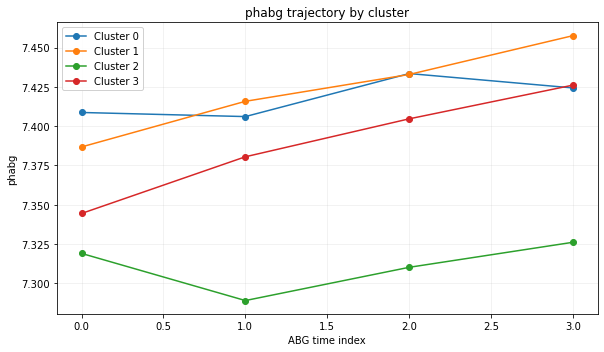

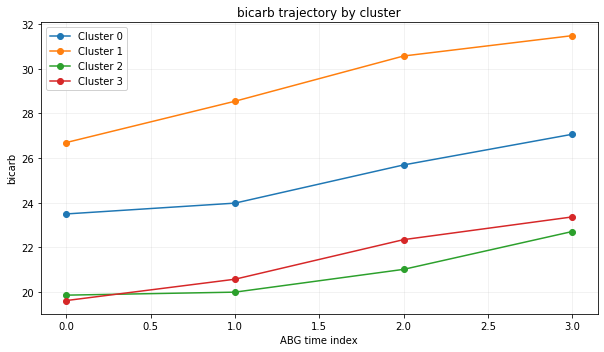

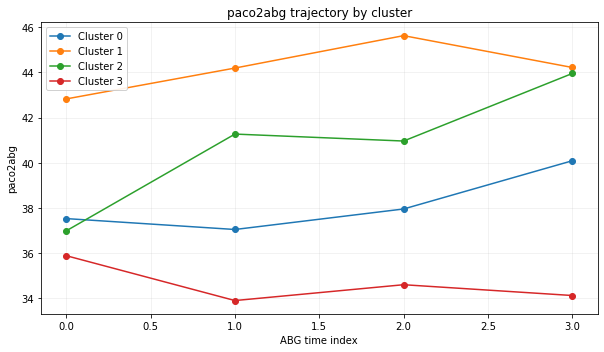

In [62]:
import matplotlib.pyplot as plt

def traj_plot(var_base, times=(0,1,2,3)):
    cols = [f"{var_base}_{t}" for t in times if f"{var_base}_{t}" in df.columns]
    use = df.dropna(subset=["cluster"]).copy()

    fig, ax = plt.subplots(figsize=(8.5,5))
    for k in sorted(use["cluster"].unique()):
        sub = use[use["cluster"]==k]
        means = [sub[c].mean() for c in cols]
        ax.plot([int(c.split("_")[-1]) for c in cols], means, marker="o", label=f"Cluster {k}")

    ax.set_xlabel("ABG time index")
    ax.set_ylabel(var_base)
    ax.set_title(f"{var_base} trajectory by cluster")
    ax.grid(alpha=0.2)
    ax.legend(framealpha=0.9)
    plt.tight_layout()
    plt.show()

traj_plot("phabg")
traj_plot("bicarb")
traj_plot("paco2abg")


In [64]:
df["cluster"].value_counts().sort_index()

cluster
0    66
1    79
2    52
3    85
Name: count, dtype: int64

In [70]:
summarize_by_cluster(df, t=0)

phabg_0                     paco2abg_0                       bicarb_0  \
          count      mean       std      count       mean        std    count   
cluster                                                                         
0            63  7.408730  0.055343         63  37.523810   5.444314       66   
1            75  7.386800  0.063078         75  42.826667   7.651838       79   
2            52  7.319038  0.102273         52  36.980769  10.131470       52   
3            83  7.344458  0.077605         83  35.879518   8.635431       85   

                             pao2abg_0                        fio2abg_0  \
              mean       std     count        mean        std     count   
cluster                                                                   
0        23.500000  3.709655        63   94.158730  41.648764        63   
1        26.696203  5.137480        75  100.213333  49.180663        75   
2        19.865385  5.715575        52   88.307692  40.023296        52   
3        19.623529  4.011817        83   98.421687  43.870130        83   

                             
             mean       std  
cluster                      
0        0.548254  0.205564  
1        0.639333  0.210259  
2        0.689808  0.214215  
3        0.655060  0.225196

In [72]:
summarize_by_cluster(df, t=1)

phabg_1                     paco2abg_1                       bicarb_1  \
          count      mean       std      count       mean        std    count   
cluster                                                                         
0            49  7.406122  0.052074         49  37.040816   5.582559       63   
1            72  7.415833  0.060275         72  44.194444   6.190950       79   
2            52  7.289038  0.102293         52  41.269231  11.022464       52   
3            74  7.380541  0.063157         74  33.891892   6.601302       83   

                             pao2abg_1                       fio2abg_1  \
              mean       std     count       mean        std     count   
cluster                                                                  
0        23.984127  2.865209        49  94.163265  26.261781        49   
1        28.544304  4.971193        72  95.222222  37.326961        72   
2        20.000000  5.029326        52  90.115385  34.366339        52   
3        20.578313  3.516929        74  96.148649  30.499801        74   

                             
             mean       std  
cluster                      
0        0.433673  0.079966  
1        0.518056  0.142983  
2        0.649038  0.185898  
3        0.506081  0.135978

In [74]:
summarize_by_cluster(df, t=2)

phabg_2                     paco2abg_2                      bicarb_2  \
          count      mean       std      count       mean       std    count   
cluster                                                                        
0            40  7.433500  0.051168         40  37.950000  5.007430       62   
1            65  7.432923  0.048789         65  45.630769  7.381500       79   
2            51  7.310196  0.075326         51  40.960784  9.862983       50   
3            64  7.404687  0.066690         64  34.593750  5.647640       80   

                             pao2abg_2                       fio2abg_2  \
              mean       std     count       mean        std     count   
cluster                                                                  
0        25.693548  2.773343        40  88.700000  23.761853        40   
1        30.569620  4.916439        65  88.200000  34.398038        65   
2        21.020000  5.176438        51  86.313725  26.385974        51   
3        22.350000  4.050629        64  84.031250  19.599942        64   

                             
             mean       std  
cluster                      
0        0.384000  0.063722  
1        0.449385  0.129938  
2        0.605882  0.174255  
3        0.455469  0.142572

In [76]:
summarize_by_cluster(df, t=3)

phabg_3                     paco2abg_3                       bicarb_3  \
          count      mean       std      count       mean        std    count   
cluster                                                                         
0            23  7.424348  0.039292         23  40.086957   4.111105       60   
1            59  7.457627  0.044192         59  44.220339   7.098003       77   
2            44  7.326136  0.060548         44  43.954545  10.115506       49   
3            52  7.426154  0.056296         52  34.115385   6.723252       79   

                             pao2abg_3                       fio2abg_3  \
              mean       std     count       mean        std     count   
cluster                                                                  
0        27.066667  2.441635        23  81.869565   9.449889        23   
1        31.480519  4.881788        59  85.254237  26.552871        59   
2        22.714286  5.318991        44  91.181818  37.921751        45   
3        23.367089  3.935953        52  90.326923  29.083194        53   

                             
             mean       std  
cluster                      
0        0.378261  0.075115  
1        0.442203  0.099431  
2        0.585556  0.169767  
3        0.475660  0.126392

In [78]:
# List columns that might encode mortality or vital status
mortality_keywords = [
    "death", "dead", "died", "mort", "status",
    "vital", "surviv", "expire", "outcome"
]

[c for c in df.columns if any(k in c.lower() for k in mortality_keywords)]


[]

In [81]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# -----------------------------
# 0) LOAD ALTA BYPT
# -----------------------------
folder = Path("/Users/sam/Documents/ARDS Python")
alta_path = folder / "alta_bypt.csv"

alta = pd.read_csv(alta_path, low_memory=False)
alta.columns = alta.columns.str.strip()

print("Path:", alta_path)
print("Shape (rows, cols):", alta.shape)
display(alta.head(10))

# -----------------------------
# 1) FIND ID + MORTALITY COLUMNS
# -----------------------------
def pick_id_col(df):
    candidates = ["ptid", "patient_id", "id", "subjid", "subject_id", "record_id"]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: any column containing "id" that looks patient-like
    id_like = [c for c in df.columns if "id" in c.lower()]
    return id_like[0] if id_like else None

def pick_mort_col(df):
    # prioritize death60, then death90, then any "death" or "mort" variable
    priority = ["death60", "death_60", "dth60", "mort60", "mortality60",
                "death90", "death_90", "dth90", "mort90", "mortality90"]
    for c in priority:
        if c in df.columns:
            return c
    # broader search
    mort_like = [c for c in df.columns if any(k in c.lower() for k in ["death", "mort"])]
    return mort_like[0] if mort_like else None

ID_COL = pick_id_col(alta)
MORT_COL = pick_mort_col(alta)

print("Detected ID_COL:", ID_COL)
print("Detected MORT_COL:", MORT_COL)

if ID_COL is None:
    raise ValueError("Could not detect patient ID column in alta_bypt.csv. Please set ID_COL manually.")
if MORT_COL is None:
    raise ValueError("Could not detect mortality column in alta_bypt.csv (e.g., death60). Please set MORT_COL manually.")

# Show possible outcome columns so you can confirm
outcome_cols = [c for c in alta.columns if any(k in c.lower() for k in ["death", "mort", "vfd", "icu", "alive"])]
print("Outcome-like columns:", outcome_cols)

# -----------------------------
# 2) PREP OUTCOMES (BINARY 0/1)
# -----------------------------
outcomes = alta[[ID_COL, MORT_COL]].copy()

# coerce to numeric if possible
outcomes[MORT_COL] = pd.to_numeric(outcomes[MORT_COL], errors="coerce")

# If coded oddly, normalize:
# - if values are already 0/1, keep
# - if values are e.g., 1/2, map {2:0,1:1}? (we won't guess; we just binarize carefully)
vals = outcomes[MORT_COL].dropna().unique()
vals_sorted = np.sort(vals)[:20]
print("Unique mortality values (first 20 sorted):", vals_sorted)

# binarize with the most common ARDSNet pattern: 1=dead, 0=alive
# if your file uses opposite, flip below.
outcomes["mortality"] = outcomes[MORT_COL].where(outcomes[MORT_COL].isin([0, 1]), np.nan)

if outcomes["mortality"].isna().mean() > 0.2:
    print(
        "\n⚠️ mortality has >20% missing after 0/1 filter.\n"
        "If your coding isn't 0/1, inspect value meanings and edit the binarization step.\n"
        "For now, I will fall back to: mortality=1 if value in the max value, 0 if in min value (only if exactly 2 unique values).\n"
    )
    uniq = np.sort(outcomes[MORT_COL].dropna().unique())
    if len(uniq) == 2:
        outcomes["mortality"] = outcomes[MORT_COL].map({uniq[0]: 0, uniq[1]: 1})
        print("Auto-mapped mortality:", {uniq[0]: 0, uniq[1]: 1})
    else:
        raise ValueError("Mortality column not 0/1 and not exactly two unique values. Please map manually.")

# keep only id + mortality
outcomes = outcomes[[ID_COL, "mortality"]].drop_duplicates(subset=[ID_COL])

print("\nMortality distribution:")
print(outcomes["mortality"].value_counts(dropna=False))

# -----------------------------
# 3) MERGE WITH YOUR CLUSTER DF
# -----------------------------
# REQUIREMENT: you already have a dataframe with clusters, called df_clustered
# It must have the same ID column (or rename appropriately)
if "df_clustered" not in globals():
    raise NameError(
        "df_clustered not found. Please ensure your clustering output dataframe is named df_clustered "
        "and contains the patient ID column plus a 'cluster' column."
    )

dfc = df_clustered.copy()
if ID_COL not in dfc.columns:
    # try to detect an ID column in dfc and rename
    alt_id = pick_id_col(dfc)
    if alt_id is None:
        raise ValueError(f"df_clustered does not contain '{ID_COL}' and no other ID-like column was detected.")
    dfc = dfc.rename(columns={alt_id: ID_COL})
    print(f"Renamed df_clustered ID column {alt_id} -> {ID_COL}")

if "cluster" not in dfc.columns:
    raise ValueError("df_clustered must contain a 'cluster' column.")

df = dfc.merge(outcomes, on=ID_COL, how="left")

print("\nAfter merge:")
print("Rows:", df.shape[0], "Cols:", df.shape[1])
print("Mortality missing rate:", df["mortality"].isna().mean())

# -----------------------------
# 4) CLUSTER-WISE MORTALITY TABLE
# -----------------------------
mort_table = (
    df.groupby("cluster")["mortality"]
      .agg(n="count", deaths="sum", mortality_rate="mean")
      .reset_index()
)
mort_table["mortality_rate_pct"] = 100 * mort_table["mortality_rate"]

display(mort_table.sort_values("cluster"))

# -----------------------------
# 5) CHI-SQUARE TEST + CRAMER'S V
# -----------------------------
ct = pd.crosstab(df["cluster"], df["mortality"])
print("\nContingency table (cluster x mortality):")
display(ct)

if ct.shape[1] == 2:
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f"Chi-square: {chi2:.4f}, df={dof}, p={p:.4g}, Cramer's V={cramers_v:.3f}")
else:
    print("⚠️ Mortality column does not have exactly 2 levels after cleaning. Check coding and binarization.")

# -----------------------------
# 6) OPTIONAL: ADJUSTED LOGISTIC REGRESSION
# -----------------------------
# Only run if you have these columns available (edit covariates as needed).
covars = []
for c in ["age", "pao2_fio2_ratio", "severity", "apachescore", "sofa"]:
    if c in df.columns:
        covars.append(c)

if len(covars) >= 1:
    formula = "mortality ~ C(cluster) + " + " + ".join(covars[:2])  # take first 1-2 covariates
    print("\nFitting adjusted model:", formula)
    m = smf.logit(formula, data=df.dropna(subset=["mortality"] + covars[:2])).fit(disp=False)
    display(m.summary2())
else:
    print("\nNo common covariates found for adjustment (e.g., age, pao2_fio2_ratio). Skipping adjusted model.")


Path: /Users/sam/Documents/ARDS Python/alta_bypt.csv
Shape (rows, cols): (282, 3752)


,ptid,b_pressors,on_propofol,randomdt,randomtm,alta,altapatient,allcrit,allcritc,qualdt,...,apache.2,vfd.2,icufd.2,cardio28.2,cns28.2,coag28.2,renal28.2,hepatic28.2,orgfree28.2,death90.2
0,06-001,0,0,0,13:54,Albuterol,1,1,1,-1,...,78,25,25,26,22,28,28,28,26,0
1,06-002,0,0,0,18:11,Albuterol,1,1,1,0,...,93,24,24,27,22,28,28,28,27,0
2,06-003,0,0,0,14:51,Albuterol,1,1,1,0,...,80,25,23,23,22,28,28,28,23,0
3,06-004,1,0,0,17:32,Albuterol,1,1,1,-2,...,129,0,0,0,0,11,20,21,0,1
4,06-005,0,0,0,8:42,Albuterol,1,1,1,-1,...,90,22,16,25,22,28,28,28,25,0
5,06-006,1,0,0,13:37,Albuterol,1,1,1,0,...,83,0,0,18,0,28,27,28,17,0
6,06-007,1,0,0,15:08,Albuterol,1,1,1,-1,...,64,13,11,26,22,27,28,26,24,0
7,06-008,1,0,0,18:16,Placebo,1,1,1,-2,...,127,0,0,10,14,16,20,20,7,1
8,06-009,0,0,0,17:27,Albuterol,1,1,1,-1,...,80,17,16,20,6,25,28,28,19,0
9,06-010,0,0,0,16:41,Albuterol,1,1,1,0,...,50,27,27,27,28,28,28,28,27,0


Detected ID_COL: ptid
Detected MORT_COL: death60
Outcome-like columns: ['icudt', 'icutm', 'icureadmit', 'icureadmitc', 'deathdt', 'death60', 'vfd', 'vfd_status', 'icufd', 'icu_query', 'micu', 'death90', 'death60.1', 'vfd.1', 'icufd.1', 'death90.1', 'death60.2', 'vfd.2', 'icufd.2', 'death90.2']
Unique mortality values (first 20 sorted): [0 1]

Mortality distribution:
mortality
0    224
1     58
Name: count, dtype: int64


NameError: df_clustered not found. Please ensure your clustering output dataframe is named df_clustered and contains the patient ID column plus a 'cluster' column.

In [83]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

folder = Path("/Users/sam/Documents/ARDS Python")
alta = pd.read_csv(folder / "alta_bypt.csv", low_memory=False)

alta.columns = alta.columns.str.strip()
print(alta.shape)
alta.head()

ID_COL = "ptid"
MORT_COL = "death90.2"   # confirmed from data preview

alta[[ID_COL, MORT_COL]].head()


(282, 3752)


,ptid,death90.2
0,06-001,0
1,06-002,0
2,06-003,0
3,06-004,1
4,06-005,0


In [85]:
mort = alta[[ID_COL, MORT_COL]].copy()
mort[MORT_COL] = pd.to_numeric(mort[MORT_COL], errors="coerce")

# Ensure binary
mort["mortality"] = mort[MORT_COL].map({0: 0, 1: 1})

print(mort["mortality"].value_counts(dropna=False))


mortality
0    221
1     61
Name: count, dtype: int64


In [87]:
# df is the dataframe you clustered earlier
# Z is the latent embedding
# gmm is the fitted GMM

df_clustered = df.copy()   # this is the df used during clustering
df_clustered["cluster"] = df["cluster"].values

df_clustered["cluster"].value_counts()



cluster
3    85
1    79
0    66
2    52
Name: count, dtype: int64

In [89]:
ID_COL = "ptid"

df_clustered = df_clustered.merge(
    mort[[ID_COL, "mortality"]],
    on=ID_COL,
    how="left"
)

print("Rows:", df_clustered.shape[0])
print("Missing mortality:", df_clustered["mortality"].isna().sum())


Rows: 282
Missing mortality: 0


In [91]:
mort_table = (
    df_clustered
    .groupby("cluster")["mortality"]
    .agg(
        n="count",
        deaths="sum",
        mortality_rate="mean"
    )
    .reset_index()
)

mort_table["mortality_rate_pct"] = 100 * mort_table["mortality_rate"]
mort_table


,cluster,n,deaths,mortality_rate,mortality_rate_pct
0,0,66,7,0.106061,10.606061
1,1,79,7,0.088608,8.860759
2,2,52,24,0.461538,46.153846
3,3,85,23,0.270588,27.058824


In [93]:
from scipy.stats import chi2_contingency
import numpy as np

ct = pd.crosstab(df_clustered["cluster"], df_clustered["mortality"])
ct


mortality,0,1
cluster,,
0,59,7
1,72,7
2,28,24
3,62,23


In [95]:
chi2, p, dof, _ = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

chi2, p, cramers_v


(32.25611911751209, 4.621746309648157e-07, 0.3382061518156188)

In [97]:
# Make sure cluster labels are integers
df_clustered["cluster"] = df_clustered["cluster"].astype(int)

# Merge into ALTA
DF = alta.merge(
    df_clustered[[ID_COL, "cluster"]],
    on=ID_COL,
    how="left"
)

print("Merged shape:", DF.shape)
print("Clusters present:\n", DF["cluster"].value_counts(dropna=False))


Merged shape: (282, 3753)
Clusters present:
 cluster
3    85
1    79
0    66
2    52
Name: count, dtype: int64


In [107]:
DF["mortality"] = DF["death90.2"].astype(int)
DF["mortality"].value_counts()
mort_table = (
    DF.dropna(subset=["cluster"])
      .groupby("cluster")["mortality"]
      .agg(n="count", deaths="sum", mortality_rate="mean")
      .reset_index()
)

mort_table["mortality_rate_pct"] = 100 * mort_table["mortality_rate"]
mort_table


,cluster,n,deaths,mortality_rate,mortality_rate_pct
0,0,66,7,0.106061,10.606061
1,1,79,7,0.088608,8.860759
2,2,52,24,0.461538,46.153846
3,3,85,23,0.270588,27.058824


In [109]:
from scipy.stats import chi2_contingency
import numpy as np

ct = pd.crosstab(DF["cluster"], DF["mortality"])
chi2, p, _, _ = chi2_contingency(ct)

n = ct.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

chi2, p, cramers_v


(32.25611911751209, 4.621746309648157e-07, 0.3382061518156188)

In [113]:
# Patsy/statsmodels doesn't like pandas nullable Int64 -> convert to numpy dtypes
d = d.copy()

# cluster: plain int (and keep it categorical in the formula via C(cluster))
d["cluster"] = d["cluster"].astype(int)

# mortality: plain int 0/1
d["mortality"] = d["mortality"].astype(int)

# pressors: plain int 0/1 (or float if you prefer)
d["b_pressors"] = pd.to_numeric(d["b_pressors"], errors="coerce").fillna(0).astype(int)

# age + pf_ratio: floats
d["age"] = pd.to_numeric(d["age"], errors="coerce").astype(float)
d["pf_ratio"] = pd.to_numeric(d["pf_ratio"], errors="coerce").astype(float)

model = smf.logit(
    "mortality ~ C(cluster) + age + pf_ratio + b_pressors",
    data=d
).fit(disp=False)

print(model.summary())


NameError: name 'd' is not defined

In [115]:
d["pf_ratio_50"] = d["pf_ratio"] / 50.0
model = smf.logit(
    "mortality ~ C(cluster) + age + pf_ratio_50 + b_pressors",
    data=d
).fit(disp=False)


NameError: name 'd' is not defined

In [117]:
import numpy as np
or_table = np.exp(model.conf_int())
or_table.columns = ["OR_2.5%", "OR_97.5%"]
or_table["OR"] = np.exp(model.params)
or_table

,OR_2.5%,OR_97.5%,OR
Intercept,3.065077,5.575042,4.133756
C(cluster)[T.1],0.958564,2.157945,1.438238
C(cluster)[T.2],2.275386,5.538855,3.550075
C(cluster)[T.3],1.768092,3.909156,2.629020


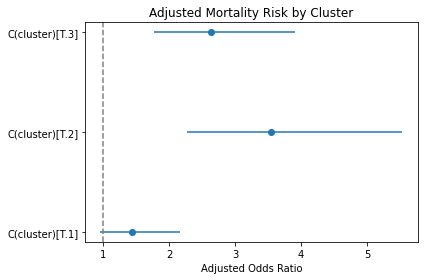

In [119]:
import matplotlib.pyplot as plt

or_df = or_table.drop("Intercept")
or_df["OR"] = np.exp(model.params.drop("Intercept"))

plt.figure(figsize=(6,4))
plt.errorbar(
    or_df["OR"],
    range(len(or_df)),
    xerr=[or_df["OR"] - or_df["OR_2.5%"], or_df["OR_97.5%"] - or_df["OR"]],
    fmt="o"
)
plt.yticks(range(len(or_df)), or_df.index)
plt.axvline(1, color="gray", linestyle="--")
plt.xlabel("Adjusted Odds Ratio")
plt.title("Adjusted Mortality Risk by Cluster")
plt.tight_layout()
plt.show()


In [122]:
import pandas as pd
import numpy as np
import re

def find_cols(patterns, cols):
    rx = re.compile("|".join(patterns), re.IGNORECASE)
    return [c for c in cols if rx.search(c)]

# Candidate columns
race_candidates = find_cols(["white", "afamer", "black", "race", "ethnic", "hisp"], alta.columns)
race_candidates[:50], len(race_candidates)


(['ethnic', 'ethnicc', 'white', 'whitec', 'afamer', 'afamerc', 'race_dsmb'], 7)

In [124]:
import numpy as np
import pandas as pd

demo = pd.DataFrame({
    "ptid": alta["ptid"],

    # Age
    "age": pd.to_numeric(alta["age"], errors="coerce"),

    # Sex
    "female": alta["gender"].map({2: 1, 1: 0}),

    # Ethnicity (ARDSNet: 2 = Hispanic, 1 = Non-Hispanic)
    "hispanic": pd.to_numeric(alta["ethnic"], errors="coerce").map({2: 1, 1: 0})
})

# ---- Race (ARDSNet indicator-style) ----
demo["race"] = "other"

white = pd.to_numeric(alta["white"], errors="coerce")
black = pd.to_numeric(alta["afamer"], errors="coerce")

demo.loc[white == 5, "race"] = "white"
demo.loc[black == 3, "race"] = "black"


In [126]:
demo["race"].value_counts()
demo["hispanic"].value_counts()
demo.describe(include="all")


,ptid,age,female,hispanic,race
count,282,282.000000,282.000000,282.000000,282
unique,282,NaN,NaN,NaN,3
top,06-001,NaN,NaN,NaN,white
freq,1,NaN,NaN,NaN,217
mean,NaN,51.631206,0.446809,0.897163,NaN
std,NaN,16.249571,0.498046,0.304286,NaN
min,NaN,17.000000,0.000000,0.000000,NaN
25%,NaN,42.250000,0.000000,1.000000,NaN
50%,NaN,52.000000,0.000000,1.000000,NaN
75%,NaN,63.000000,1.000000,1.000000,NaN


In [128]:
import pandas as pd
import numpy as np
from scipy import stats

CLUSTER_COL = "cluster"

def summarize_continuous(df, var):
    # Coerce to numeric safely
    x = pd.to_numeric(df[var], errors="coerce")
    tmp = df[[CLUSTER_COL]].copy()
    tmp[var] = x

    out = {}
    groups = tmp.groupby(CLUSTER_COL)[var]

    for k, g in groups:
        g = g.dropna()
        out[k] = f"{g.mean():.2f} ± {g.std():.2f}"

    arrays = [g.dropna().values for _, g in groups if g.dropna().shape[0] > 0]

    # ANOVA if possible; otherwise Kruskal-Wallis
    p = np.nan
    try:
        if len(arrays) >= 2 and all(len(a) > 1 for a in arrays):
            f, p = stats.f_oneway(*arrays)
    except Exception:
        try:
            h, p = stats.kruskal(*arrays)
        except Exception:
            p = np.nan

    return out, p

DF["pao2abg_0"] = pd.to_numeric(DF["pao2abg_0"], errors="coerce")
DF["fio2abg_0"] = pd.to_numeric(DF["fio2abg_0"], errors="coerce")
DF["pf_ratio"] = DF["pao2abg_0"] / DF["fio2abg_0"]

for col in ["age","phabg_0","paco2abg_0","bicarb_0","pao2abg_0","fio2abg_0","pf_ratio"]:
    if col in DF.columns:
        print(col, DF[col].dtype, DF[col].head(3).tolist())


age int64 [49, 19, 76]
phabg_0 object ['7.33', '7.43', '7.32']
paco2abg_0 object ['45', '34', '39']
bicarb_0 int64 [22, 22, 18]
pao2abg_0 float64 [202.0, 136.0, 80.0]
fio2abg_0 float64 [0.7, 1.0, 0.5]
pf_ratio float64 [288.5714285714286, 136.0, 160.0]


In [130]:
import pandas as pd
import numpy as np

# ====== REQUIRED COLUMNS ======
CLUSTER_COL = "cluster"
ID_COL = "ptid"
MORT_COL = "mortality"   # or death90.2 if you use that directly

# ====== COERCE NUMERIC LABS / VITALS THAT OFTEN IMPORT AS STRINGS ======
to_num = [
    # day 0 ABG core
    "phabg_0", "paco2abg_0", "pao2abg_0", "fio2abg_0", "bicarb_0",
    # day 1-3 ABG core (if present)
    "phabg_1","paco2abg_1","pao2abg_1","fio2abg_1","bicarb_1",
    "phabg_2","paco2abg_2","pao2abg_2","fio2abg_2","bicarb_2",
    "phabg_3","paco2abg_3","pao2abg_3","fio2abg_3","bicarb_3",
    # common baseline covariates you may include later
    "age", "map", "cvp_0", "cvp_1", "resp_0", "resp_1",
    "pplat_0", "pplat_1", "peep_0", "peep_1", "tidal_0", "tidal_1"
]

for c in to_num:
    if c in DF.columns:
        DF[c] = pd.to_numeric(DF[c], errors="coerce")

# cluster should be plain int (NOT pandas Int64 extension)
if CLUSTER_COL in DF.columns:
    DF[CLUSTER_COL] = pd.to_numeric(DF[CLUSTER_COL], errors="coerce").astype("int")

# Pressors should be numeric 0/1
if "b_pressors" in DF.columns:
    DF["b_pressors"] = pd.to_numeric(DF["b_pressors"], errors="coerce")

# PF ratio (baseline)
if "pao2abg_0" in DF.columns and "fio2abg_0" in DF.columns:
    DF["pf_ratio"] = DF["pao2abg_0"] / DF["fio2abg_0"]


In [132]:
# Check available columns
print([c for c in DF.columns if "gender" in c.lower()])

# gender: 2 = female, 1 = male
DF["female"] = np.where(DF["gender"] == 2, 1,
                 np.where(DF["gender"] == 1, 0, np.nan))

DF["female"] = DF["female"].astype("float")
DF["female"].value_counts(dropna=False)
DF["hispanic"] = np.where(DF["ethnic"] == 2, 1,
                   np.where(DF["ethnic"] == 1, 0, np.nan))


['gender', 'genderc']


In [134]:
import numpy as np
import pandas as pd

# Make sure these are numeric
DF["white"]  = pd.to_numeric(DF.get("white"),  errors="coerce")
DF["afamer"] = pd.to_numeric(DF.get("afamer"), errors="coerce")

# race: black if afamer==3, else white if white==5, else other
DF["race"] = np.where(DF["afamer"] == 3, "black",
               np.where(DF["white"] == 5, "white", "other"))

DF["race"].value_counts(dropna=False)

# race ∈ {"white","black","other"}
DF["race"].value_counts()

race_tab = pd.crosstab(DF["cluster"], DF["race"])
race_p = stats.chi2_contingency(race_tab)[1]
race_tab, race_p

missing = [c for c in ["race", "female", "hispanic"] if c not in DF.columns]
print("Missing derived cols:", missing)

Missing derived cols: []


In [136]:
rows = []

# -------------------------
# CONTINUOUS VARIABLES
# -------------------------
continuous_vars = {
    "Age, years": "age",
    "pH (Day 0)": "phabg_0",
    "PaCO₂ (mm Hg, Day 0)": "paco2abg_0",
    "Bicarbonate (mEq/L, Day 0)": "bicarb_0",
    "PaO₂/FiO₂ ratio (Day 0)": "pf_ratio"
}

for label, var in continuous_vars.items():
    groups = DF.groupby("cluster")[var]
    row = {"Variable": label}
    for k, g in groups:
        row[f"Cluster {k}"] = f"{g.mean():.2f} ± {g.std():.2f}"
    row["P value"] = f"{stats.f_oneway(*[g.dropna() for _, g in groups])[1]:.3e}"
    rows.append(row)

# -------------------------
# CATEGORICAL VARIABLES
# -------------------------
categorical_vars = {
    "Female sex, n (%)": "female",
    "Hispanic ethnicity, n (%)": "hispanic",
    "Vasopressors at baseline, n (%)": "b_pressors",
    "ICU mortality, n (%)": "mortality"
}

for label, var in categorical_vars.items():
    row = {"Variable": label}
    tab = pd.crosstab(DF["cluster"], DF[var])
    for k in sorted(DF["cluster"].unique()):
        if 1 in tab.columns and k in tab.index:
            n = tab.loc[k, 1]
            N = tab.loc[k].sum()
            row[f"Cluster {k}"] = f"{n}/{N} ({100*n/N:.1f}%)"
        else:
            row[f"Cluster {k}"] = "0/0 (0%)"
    row["P value"] = f"{stats.chi2_contingency(tab)[1]:.3e}"
    rows.append(row)

table1 = pd.DataFrame(rows)
table1


,Variable,Cluster 0,Cluster 1,Cluster 2,Cluster 3,P value
0,"Age, years",54.62 ± 17.08,46.86 ± 15.56,52.33 ± 14.61,53.32 ± 16.48,1.736e-02
1,pH (Day 0),7.41 ± 0.06,7.39 ± 0.06,7.32 ± 0.10,7.34 ± 0.08,1.378e-10
2,"PaCO₂ (mm Hg, Day 0)",37.52 ± 5.44,42.83 ± 7.65,36.98 ± 10.13,35.88 ± 8.64,7.742e-07
3,"Bicarbonate (mEq/L, Day 0)",23.50 ± 3.71,26.70 ± 5.14,19.87 ± 5.72,19.62 ± 4.01,4.058e-21
4,PaO₂/FiO₂ ratio (Day 0),183.19 ± 68.28,172.41 ± 100.17,137.41 ± 64.33,160.85 ± 66.91,1.271e-02
5,"Female sex, n (%)",29/66 (43.9%),33/79 (41.8%),25/52 (48.1%),39/85 (45.9%),9.016e-01
6,"Hispanic ethnicity, n (%)",60/66 (90.9%),71/79 (89.9%),43/52 (82.7%),79/85 (92.9%),2.790e-01
7,"Vasopressors at baseline, n (%)",17/66 (25.8%),23/79 (29.1%),33/52 (63.5%),42/85 (49.4%),2.143e-05
8,"ICU mortality, n (%)",7/66 (10.6%),7/79 (8.9%),24/52 (46.2%),23/85 (27.1%),4.622e-07


In [138]:
import numpy as np

# Initialize race as object dtype (string-safe)
DF["race"] = pd.Series(index=DF.index, dtype="object")

DF.loc[DF["afamer"] == 3, "race"] = "Black"
DF.loc[(DF["white"] == 5) & DF["race"].isna(), "race"] = "White"
DF.loc[DF["race"].isna(), "race"] = "Other"


In [140]:
DF["race"].value_counts()
DF["race"].value_counts(dropna=False)


race
White    217
Black     46
Other     19
Name: count, dtype: int64

In [142]:
DF["race"] = pd.Categorical(
    DF["race"],
    categories=["White", "Black", "Other"],
    ordered=False
)


In [144]:
import pandas as pd
import numpy as np

# --- REQUIRED ---
ID_COL = "ptid"
CLUSTER_COL = "cluster"

# mortality source in ALTA
RAW_MORT_COL = "death90.2"   # change if you want death60 etc
MORT_COL = "mortality"

# 1) start from ALTA
DF = alta.copy()

# 2) attach cluster labels (choose ONE approach below)

# ---------- Approach A: you have df_clustered with ptid + cluster ----------
# Example: df_clustered columns: ["ptid","cluster"]
if "df_clustered" in globals():
    if ID_COL in df_clustered.columns and CLUSTER_COL in df_clustered.columns:
        DF = DF.merge(df_clustered[[ID_COL, CLUSTER_COL]], on=ID_COL, how="left")

# ---------- Approach B: you have a mapping dict or Series keyed by ptid ----------
# Example: cluster_map = {"06-001":0, "06-002":1, ...}
if CLUSTER_COL not in DF.columns or DF[CLUSTER_COL].isna().all():
    if "cluster_map" in globals():
        DF[CLUSTER_COL] = DF[ID_COL].map(cluster_map)

# ---------- Approach C: load from a CSV you previously saved ----------
# Example: a file with columns ptid,cluster
# Uncomment if needed:
# clusters_csv = "alta_clusters.csv"
# cdf = pd.read_csv(clusters_csv)
# DF = DF.merge(cdf[[ID_COL, CLUSTER_COL]], on=ID_COL, how="left")

# 3) sanity check
if CLUSTER_COL not in DF.columns or DF[CLUSTER_COL].isna().all():
    raise ValueError(
        "Cluster labels still missing.\n"
        "Print what objects you have using: [k for k in globals() if 'cluster' in k.lower()]\n"
        "Then use Approach A/B/C to attach them."
    )

DF[CLUSTER_COL] = pd.to_numeric(DF[CLUSTER_COL], errors="coerce").astype("Int64")

# 4) create mortality from ALTA
if RAW_MORT_COL not in DF.columns:
    raise ValueError(f"RAW_MORT_COL='{RAW_MORT_COL}' not found in DF columns.")
DF[MORT_COL] = pd.to_numeric(DF[RAW_MORT_COL], errors="coerce")

print("Clusters attached. Counts:")
print(DF[CLUSTER_COL].value_counts(dropna=False).sort_index())
print("Mortality counts:")
print(DF[MORT_COL].value_counts(dropna=False))


Clusters attached. Counts:
cluster
0    66
1    79
2    52
3    85
Name: count, dtype: Int64
Mortality counts:
mortality
0    221
1     61
Name: count, dtype: int64


In [146]:
[k for k in globals().keys() if "cluster" in k.lower()]


['cluster_km',
 'cluster_gmm',
 'summarize_by_cluster',
 'plot_davenport_flower_with_clusters',
 'plot_davenport_clusters',
 'plot_cluster_feature_heatmap',
 'plot_distance_by_cluster',
 'plot_cluster_trajectories',
 'df_clustered',
 'CLUSTER_COL']

In [148]:
[k for k in globals().keys() if "cluster" in k.lower()]

['cluster_km',
 'cluster_gmm',
 'summarize_by_cluster',
 'plot_davenport_flower_with_clusters',
 'plot_davenport_clusters',
 'plot_cluster_feature_heatmap',
 'plot_distance_by_cluster',
 'plot_cluster_trajectories',
 'df_clustered',
 'CLUSTER_COL']


TABLE 1 (publication-style):


,Variable,Cluster 0,Cluster 1,Cluster 2,Cluster 3,P value
0,"Age, years",54.62 ± 17.08,46.86 ± 15.56,52.33 ± 14.61,53.32 ± 16.48,1.736e-02
1,pH (Day 0),7.41 ± 0.06,7.39 ± 0.06,7.32 ± 0.10,7.34 ± 0.08,1.378e-10
2,"Race (White/Black/Other), n (%)",White 48 (72.7%); Black 12 (18.2%); Other 6 (9...,White 62 (78.5%); Black 12 (15.2%); Other 5 (6...,White 38 (73.1%); Black 12 (23.1%); Other 2 (3...,White 69 (81.2%); Black 10 (11.8%); Other 6 (7...,6.180e-01
3,"PaCO₂ (mm Hg, Day 0)",37.52 ± 5.44,42.83 ± 7.65,36.98 ± 10.13,35.88 ± 8.64,7.742e-07
4,"Bicarbonate (mEq/L, Day 0)",23.50 ± 3.71,26.70 ± 5.14,19.87 ± 5.72,19.62 ± 4.01,4.058e-21
5,PaO₂/FiO₂ ratio (Day 0),183.19 ± 68.28,172.41 ± 100.17,137.41 ± 64.33,160.85 ± 66.91,1.271e-02
6,"Female sex, n (%)",29/66 (43.9%),33/79 (41.8%),25/52 (48.1%),39/85 (45.9%),9.016e-01
7,"Hispanic ethnicity, n (%)",60/66 (90.9%),71/79 (89.9%),43/52 (82.7%),79/85 (92.9%),2.790e-01
8,"Vasopressors at baseline, n (%)",17/66 (25.8%),23/79 (29.1%),33/52 (63.5%),42/85 (49.4%),2.143e-05
9,"90-day mortality, n (%)",7/66 (10.6%),7/79 (8.9%),24/52 (46.2%),23/85 (27.1%),4.622e-07


Saved: ALTA_Table1_by_cluster.csv

N used in adjusted model: 273
cluster
0    63
1    75
2    52
3    83
Name: count, dtype: int64
                           Logit Regression Results                           
Dep. Variable:              mortality   No. Observations:                  273
Model:                          Logit   Df Residuals:                      266
Method:                           MLE   Df Model:                            6
Date:                Sat, 27 Dec 2025   Pseudo R-squ.:                  0.2097
Time:                        19:33:23   Log-Likelihood:                -113.63
converged:                       True   LL-Null:                       -143.77
Covariance Type:            nonrobust   LLR p-value:                 3.936e-11
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -5.5615      0.958     -5.804      0.000      -7.4

,cluster,OR,OR_2.5%,OR_97.5%,p
1,1,1.044991,0.312456,3.494908,0.943045
2,2,8.490782,2.881530,25.019131,0.000105
3,3,3.240613,1.191155,8.816292,0.021306


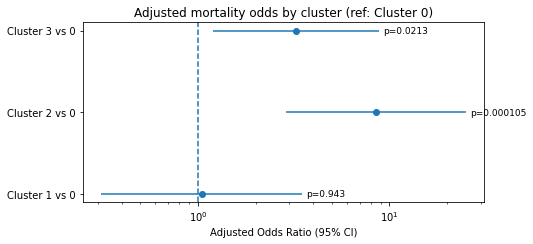

Saved: ALTA_Adjusted_OR_ForestPlot.png

Pairwise adjusted cluster comparisons (Wald tests):


,Comparison,Wald p (formatted)
0,1 vs 0,9.430e-01
3,1 vs 2,1.171e-04
4,1 vs 3,2.904e-02
1,2 vs 0,1.047e-04
5,2 vs 3,1.857e-02
2,3 vs 0,2.131e-02


Saved: ALTA_Adjusted_PairwiseClusterPvalues.csv


In [150]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# =========================
# 0) SETTINGS
# =========================
ID_COL = "ptid"
CLUSTER_COL = "cluster"
RAW_MORT_COL = "death90.2"   # 90-day mortality in ALTA; change if you want other endpoint
MORT_COL = "mortality"

# key baseline physiologic variables (Day 0)
CONT_VARS = {
    "Age, years": "age",
    "pH (Day 0)": "phabg_0",
    "PaCO₂ (mm Hg, Day 0)": "paco2abg_0",
    "Bicarbonate (mEq/L, Day 0)": "bicarb_0",
    "PaO₂/FiO₂ ratio (Day 0)": "pf_ratio",
}

BIN_VARS = {
    "Female sex, n (%)": "female",
    "Hispanic ethnicity, n (%)": "hispanic",
    "Vasopressors at baseline, n (%)": "b_pressors",
    "90-day mortality, n (%)": MORT_COL,
}

# =========================
# 1) MERGE CLUSTERS INTO ALTA
# =========================
DF = alta.copy()

if "df_clustered" not in globals():
    raise ValueError("df_clustered not found in globals(). You said it exists—double-check variable name.")
if ID_COL not in df_clustered.columns or CLUSTER_COL not in df_clustered.columns:
    raise ValueError("df_clustered must contain columns ['ptid','cluster'].")

DF = DF.merge(df_clustered[[ID_COL, CLUSTER_COL]], on=ID_COL, how="left")
if DF[CLUSTER_COL].isna().all():
    raise ValueError("Cluster merge failed: cluster is all-NA after merge. Check ptid formatting in both tables.")

DF[CLUSTER_COL] = pd.to_numeric(DF[CLUSTER_COL], errors="coerce").astype(int)

# =========================
# 2) OUTCOME + BASELINE DERIVED VARS
# =========================
# Mortality
DF[MORT_COL] = pd.to_numeric(DF[RAW_MORT_COL], errors="coerce")

# Numeric coercion for ABGs that sometimes load as strings
for c in ["phabg_0","paco2abg_0","bicarb_0","pao2abg_0","fio2abg_0"]:
    if c in DF.columns:
        DF[c] = pd.to_numeric(DF[c], errors="coerce")

# PF ratio
DF["pf_ratio"] = DF["pao2abg_0"] / DF["fio2abg_0"]

# =========================
# 3) DEMOGRAPHICS (female, hispanic, race)
# =========================
# female: ALTA often uses gender=2 female, 1 male. If you already made female earlier, this won’t overwrite unless missing.
if "female" not in DF.columns or DF["female"].isna().all():
    if "gender" in DF.columns:
        g = pd.to_numeric(DF["gender"], errors="coerce")
        DF["female"] = np.where(g == 2, 1, np.where(g == 1, 0, np.nan))
    else:
        DF["female"] = np.nan

# hispanic: your prior exploration suggests ethnic=1 non-hispanic, 2 hispanic OR vice versa.
# You previously computed "hispanic mean ~0.897" which implies you were coding 1 as "hispanic".
# We'll implement: hispanic=1 if ethnic==2 (most common) BUT we will auto-detect by distribution:
DF["ethnic"] = pd.to_numeric(DF.get("ethnic", np.nan), errors="coerce")
if DF["ethnic"].notna().any():
    # If ethnic==2 dominates (as in your counts), assume 2 = Hispanic -> hispanic=1
    # If ethnic==1 dominates, assume 1 = Hispanic -> hispanic=1
    vc = DF["ethnic"].value_counts(dropna=True)
    majority = vc.index[0]
    if majority == 2:
        DF["hispanic"] = np.where(DF["ethnic"] == 2, 1, np.where(DF["ethnic"] == 1, 0, np.nan))
    else:
        DF["hispanic"] = np.where(DF["ethnic"] == 1, 1, np.where(DF["ethnic"] == 2, 0, np.nan))
else:
    DF["hispanic"] = np.nan

# race from white==5 and afamer==3 (your R logic)
DF["white"] = pd.to_numeric(DF.get("white", np.nan), errors="coerce")
DF["afamer"] = pd.to_numeric(DF.get("afamer", np.nan), errors="coerce")

DF["race"] = "Other"  # initialize as object (prevents dtype warning)
DF.loc[DF["white"] == 5, "race"] = "White"
DF.loc[DF["afamer"] == 3, "race"] = "Black"
DF["race"] = DF["race"].astype("category")

# baseline pressors
DF["b_pressors"] = pd.to_numeric(DF.get("b_pressors", np.nan), errors="coerce")

# =========================
# 4) TABLE 1 HELPERS
# =========================
def fmt_mean_sd(x):
    return f"{np.nanmean(x):.2f} ± {np.nanstd(x, ddof=1):.2f}"

def summarize_continuous(df, var):
    out = {}
    groups = df.groupby(CLUSTER_COL)[var]
    arrays = []
    for k, g in groups:
        gv = pd.to_numeric(g, errors="coerce").dropna().values
        out[k] = fmt_mean_sd(gv) if len(gv) else "NA"
        arrays.append(gv)

    # Omnibus p: ANOVA if all groups have >=2 values, else NA
    if all(len(a) >= 2 for a in arrays) and len(arrays) >= 2:
        p = stats.f_oneway(*arrays).pvalue
    else:
        p = np.nan
    return out, p

def summarize_binary(df, var):
    out = {}
    # ensure numeric 0/1
    v = pd.to_numeric(df[var], errors="coerce")
    df2 = df.copy()
    df2[var] = v

    tab = pd.crosstab(df2[CLUSTER_COL], df2[var])
    # guarantee columns 0 and 1 exist
    for col in [0,1]:
        if col not in tab.columns:
            tab[col] = 0
    tab = tab[[0,1]].sort_index()

    for k in sorted(df2[CLUSTER_COL].dropna().unique()):
        n1 = int(tab.loc[k, 1]) if k in tab.index else 0
        n = int(tab.loc[k, 0] + tab.loc[k, 1]) if k in tab.index else 0
        out[k] = f"{n1}/{n} ({(n1/n*100):.1f}%)" if n > 0 else "NA"

    # Omnibus p: chi-square (fallback Fisher if any expected <5 and table is 2xK not supported by scipy fisher)
    if tab.values.sum() == 0:
        p = np.nan
    else:
        chi2, p, dof, exp = stats.chi2_contingency(tab.values)
    return out, p

def summarize_race(df):
    # show White/Black/Other across clusters; p via chi-square
    tab = pd.crosstab(df[CLUSTER_COL], df["race"]).reindex(sorted(df[CLUSTER_COL].unique()), axis=0)
    # Format each cluster as "White n(%); Black n(%); Other n(%)"
    out = {}
    for k in tab.index:
        row = tab.loc[k]
        n = int(row.sum())
        if n == 0:
            out[k] = "NA"
        else:
            parts = []
            for lvl in ["White","Black","Other"]:
                c = int(row.get(lvl, 0))
                parts.append(f"{lvl} {c} ({c/n*100:.1f}%)")
            out[k] = "; ".join(parts)

    chi2, p, dof, exp = stats.chi2_contingency(tab.values)
    return out, p

# =========================
# 5) BUILD TABLE 1
# =========================
rows = []

# Continuous
for label, var in CONT_VARS.items():
    vals, p = summarize_continuous(DF, var)
    row = {"Variable": label, "P value": (f"{p:.3e}" if np.isfinite(p) else "NA")}
    for k in sorted(DF[CLUSTER_COL].unique()):
        row[f"Cluster {k}"] = vals.get(k, "NA")
    rows.append(row)

# Binary
for label, var in BIN_VARS.items():
    vals, p = summarize_binary(DF, var)
    row = {"Variable": label, "P value": (f"{p:.3e}" if np.isfinite(p) else "NA")}
    for k in sorted(DF[CLUSTER_COL].unique()):
        row[f"Cluster {k}"] = vals.get(k, "NA")
    rows.append(row)

# Race (categorical, multi-level)
race_vals, race_p = summarize_race(DF)
race_row = {"Variable": "Race (White/Black/Other), n (%)", "P value": f"{race_p:.3e}"}
for k in sorted(DF[CLUSTER_COL].unique()):
    race_row[f"Cluster {k}"] = race_vals.get(k, "NA")
rows.insert(2, race_row)  # put near demographics

table1 = pd.DataFrame(rows)

# Order columns nicely
cluster_cols = [f"Cluster {k}" for k in sorted(DF[CLUSTER_COL].unique())]
table1 = table1[["Variable"] + cluster_cols + ["P value"]]

print("\nTABLE 1 (publication-style):")
display(table1)

# Optional: save
table1.to_csv("ALTA_Table1_by_cluster.csv", index=False)
print("Saved: ALTA_Table1_by_cluster.csv")

# =========================
# 6) ADJUSTED LOGISTIC REGRESSION + OR TABLE
# =========================
# Model covariates: cluster + age + pf_ratio + baseline pressors
model_df = DF[[MORT_COL, CLUSTER_COL, "age", "pf_ratio", "b_pressors"]].copy()
model_df["age"] = pd.to_numeric(model_df["age"], errors="coerce")
model_df["pf_ratio"] = pd.to_numeric(model_df["pf_ratio"], errors="coerce")
model_df["b_pressors"] = pd.to_numeric(model_df["b_pressors"], errors="coerce")
model_df = model_df.dropna(subset=[MORT_COL, CLUSTER_COL, "age", "pf_ratio", "b_pressors"])

print("\nN used in adjusted model:", len(model_df))
print(model_df[CLUSTER_COL].value_counts().sort_index())

fit = smf.logit(f"{MORT_COL} ~ C({CLUSTER_COL}) + age + pf_ratio + b_pressors", data=model_df).fit(disp=False)
print(fit.summary())

params = fit.params
conf = fit.conf_int()
pvals = fit.pvalues

or_df = pd.DataFrame({
    "term": params.index,
    "OR": np.exp(params.values),
    "OR_2.5%": np.exp(conf[0].values),
    "OR_97.5%": np.exp(conf[1].values),
    "p": pvals.values
})

# Keep cluster terms only for forest plot
cluster_terms = [t for t in or_df["term"] if t.startswith(f"C({CLUSTER_COL})[T.")]
or_clusters = or_df[or_df["term"].isin(cluster_terms)].copy()
or_clusters["cluster"] = or_clusters["term"].str.extract(r"\[T\.(\d+)\]").astype(int)

print("\nAdjusted OR table (clusters vs ref=0):")
display(or_clusters[["cluster","OR","OR_2.5%","OR_97.5%","p"]].sort_values("cluster"))

# =========================
# 7) FOREST PLOT (Adjusted ORs)
# =========================
# Sort by cluster
or_clusters = or_clusters.sort_values("cluster")

y = np.arange(len(or_clusters))
or_vals = or_clusters["OR"].values
lo = or_clusters["OR_2.5%"].values
hi = or_clusters["OR_97.5%"].values
p = or_clusters["p"].values
labels = [f"Cluster {c} vs 0" for c in or_clusters["cluster"].values]

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.errorbar(or_vals, y, xerr=[or_vals - lo, hi - or_vals], fmt='o')
ax.axvline(1.0, linestyle='--')

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Adjusted Odds Ratio (95% CI)")
ax.set_title("Adjusted mortality odds by cluster (ref: Cluster 0)")
ax.set_xscale("log")

# annotate p-values
for i, (val, pi) in enumerate(zip(or_vals, p)):
    ax.text(hi[i] * 1.05, i, f"p={pi:.3g}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("ALTA_Adjusted_OR_ForestPlot.png", dpi=300)
plt.show()
print("Saved: ALTA_Adjusted_OR_ForestPlot.png")

# =========================
# 8) PAIRWISE CLUSTER COMPARISONS (Adjusted)
# =========================
# Wald tests for differences between cluster coefficients:
# H0: beta_clusterA - beta_clusterB = 0
# Note: cluster 0 is reference; comparisons involving 0 are directly from coefficients.
coef_names = fit.params.index.tolist()

def coef_for_cluster(k):
    if k == 0:
        return None  # reference
    name = f"C({CLUSTER_COL})[T.{k}]"
    if name not in coef_names:
        raise ValueError(f"Missing coefficient for cluster {k}: {name}")
    return name

clusters = sorted(model_df[CLUSTER_COL].unique())
pairs = []
for i in range(len(clusters)):
    for j in range(i+1, len(clusters)):
        a, b = clusters[i], clusters[j]
        if a == 0:
            # test beta_b = 0 (already in model pvalue)
            name_b = coef_for_cluster(b)
            pval = float(fit.pvalues[name_b])
            pairs.append({"Comparison": f"{b} vs 0", "Wald p": pval})
        elif b == 0:
            name_a = coef_for_cluster(a)
            pval = float(fit.pvalues[name_a])
            pairs.append({"Comparison": f"{a} vs 0", "Wald p": pval})
        else:
            name_a = coef_for_cluster(a)
            name_b = coef_for_cluster(b)
            # linear hypothesis: beta_a - beta_b = 0
            L = np.zeros(len(coef_names))
            L[coef_names.index(name_a)] = 1
            L[coef_names.index(name_b)] = -1
            test = fit.t_test(L)
            pairs.append({"Comparison": f"{a} vs {b}", "Wald p": float(test.pvalue)})

pairwise = pd.DataFrame(pairs).sort_values("Comparison")
pairwise["Wald p (formatted)"] = pairwise["Wald p"].map(lambda x: f"{x:.3e}")
print("\nPairwise adjusted cluster comparisons (Wald tests):")
display(pairwise[["Comparison","Wald p (formatted)"]])

pairwise.to_csv("ALTA_Adjusted_PairwiseClusterPvalues.csv", index=False)
print("Saved: ALTA_Adjusted_PairwiseClusterPvalues.csv")


In [157]:
# Replace the single "Race (White/Black/Other)" row with 3 separate rows
tab_race = pd.crosstab(DF[CLUSTER_COL], DF["race"]).reindex(sorted(DF[CLUSTER_COL].unique()), axis=0)
race_rows = []
for lvl in ["White", "Black", "Other"]:
    row = {"Variable": f"Race: {lvl}, n (%)", "P value": "—"}  # omit p on subrows
    for k in sorted(DF[CLUSTER_COL].unique()):
        n = int(tab_race.loc[k].sum())
        c = int(tab_race.loc[k, lvl]) if lvl in tab_race.columns else 0
        row[f"Cluster {k}"] = f"{c}/{n} ({(c/n*100):.1f}%)" if n else "NA"
    race_rows.append(row)

# put omnibus p-value row first
race_p_row = {"Variable": "Race (overall), P value", "P value": f"{race_p:.3e}"}
for k in sorted(DF[CLUSTER_COL].unique()):
    race_p_row[f"Cluster {k}"] = ""
race_rows = [race_p_row] + race_rows


In [159]:
# Replace the single "Race (White/Black/Other)" row with 3 separate rows
tab_race = pd.crosstab(DF[CLUSTER_COL], DF["race"]).reindex(sorted(DF[CLUSTER_COL].unique()), axis=0)
race_rows = []
for lvl in ["White", "Black", "Other"]:
    row = {"Variable": f"Race: {lvl}, n (%)", "P value": "—"}  # omit p on subrows
    for k in sorted(DF[CLUSTER_COL].unique()):
        n = int(tab_race.loc[k].sum())
        c = int(tab_race.loc[k, lvl]) if lvl in tab_race.columns else 0
        row[f"Cluster {k}"] = f"{c}/{n} ({(c/n*100):.1f}%)" if n else "NA"
    race_rows.append(row)

# put omnibus p-value row first
race_p_row = {"Variable": "Race (overall), P value", "P value": f"{race_p:.3e}"}
for k in sorted(DF[CLUSTER_COL].unique()):
    race_p_row[f"Cluster {k}"] = ""
race_rows = [race_p_row] + race_rows


In [161]:
pd.set_option("display.max_colwidth", None)
display(table1)


,Variable,Cluster 0,Cluster 1,Cluster 2,Cluster 3,P value
0,"Age, years",54.62 ± 17.08,46.86 ± 15.56,52.33 ± 14.61,53.32 ± 16.48,1.736e-02
1,pH (Day 0),7.41 ± 0.06,7.39 ± 0.06,7.32 ± 0.10,7.34 ± 0.08,1.378e-10
2,"Race (White/Black/Other), n (%)",White 48 (72.7%); Black 12 (18.2%); Other 6 (9.1%),White 62 (78.5%); Black 12 (15.2%); Other 5 (6.3%),White 38 (73.1%); Black 12 (23.1%); Other 2 (3.8%),White 69 (81.2%); Black 10 (11.8%); Other 6 (7.1%),6.180e-01
3,"PaCO₂ (mm Hg, Day 0)",37.52 ± 5.44,42.83 ± 7.65,36.98 ± 10.13,35.88 ± 8.64,7.742e-07
4,"Bicarbonate (mEq/L, Day 0)",23.50 ± 3.71,26.70 ± 5.14,19.87 ± 5.72,19.62 ± 4.01,4.058e-21
5,PaO₂/FiO₂ ratio (Day 0),183.19 ± 68.28,172.41 ± 100.17,137.41 ± 64.33,160.85 ± 66.91,1.271e-02
6,"Female sex, n (%)",29/66 (43.9%),33/79 (41.8%),25/52 (48.1%),39/85 (45.9%),9.016e-01
7,"Hispanic ethnicity, n (%)",60/66 (90.9%),71/79 (89.9%),43/52 (82.7%),79/85 (92.9%),2.790e-01
8,"Vasopressors at baseline, n (%)",17/66 (25.8%),23/79 (29.1%),33/52 (63.5%),42/85 (49.4%),2.143e-05
9,"90-day mortality, n (%)",7/66 (10.6%),7/79 (8.9%),24/52 (46.2%),23/85 (27.1%),4.622e-07


In [163]:
# Add N row at top
n_row = {"Variable": "N", "P value": "—"}
for k in sorted(DF[CLUSTER_COL].unique()):
    n_row[f"Cluster {k}"] = str((DF[CLUSTER_COL] == k).sum())
table1 = pd.concat([pd.DataFrame([n_row]), table1], ignore_index=True)


In [165]:
DF["alta_arm"] = DF["alta"].astype(str).str.title()  # Albuterol / Placebo
arm_tab = pd.crosstab(DF[CLUSTER_COL], DF["alta_arm"])
chi2, p_arm, *_ = stats.chi2_contingency(arm_tab.values)

arm_row = {"Variable": "Treatment arm (Albuterol), n (%)", "P value": f"{p_arm:.3e}"}
for k in sorted(DF[CLUSTER_COL].unique()):
    n = int(arm_tab.loc[k].sum())
    c = int(arm_tab.loc[k].get("Albuterol", 0))
    arm_row[f"Cluster {k}"] = f"{c}/{n} ({(c/n*100):.1f}%)" if n else "NA"

# Insert near the top (after N)
table1 = pd.concat([table1.iloc[:1], pd.DataFrame([arm_row]), table1.iloc[1:]], ignore_index=True)


In [167]:
table1

,Variable,P value,Cluster 0,Cluster 1,Cluster 2,Cluster 3
0,N,—,66,79,52,85
1,"Treatment arm (Albuterol), n (%)",2.554e-02,43/66 (65.2%),35/79 (44.3%),33/52 (63.5%),41/85 (48.2%)
2,"Age, years",1.736e-02,54.62 ± 17.08,46.86 ± 15.56,52.33 ± 14.61,53.32 ± 16.48
3,pH (Day 0),1.378e-10,7.41 ± 0.06,7.39 ± 0.06,7.32 ± 0.10,7.34 ± 0.08
4,"Race (White/Black/Other), n (%)",6.180e-01,White 48 (72.7%); Black 12 (18.2%); Other 6 (9.1%),White 62 (78.5%); Black 12 (15.2%); Other 5 (6.3%),White 38 (73.1%); Black 12 (23.1%); Other 2 (3.8%),White 69 (81.2%); Black 10 (11.8%); Other 6 (7.1%)
5,"PaCO₂ (mm Hg, Day 0)",7.742e-07,37.52 ± 5.44,42.83 ± 7.65,36.98 ± 10.13,35.88 ± 8.64
6,"Bicarbonate (mEq/L, Day 0)",4.058e-21,23.50 ± 3.71,26.70 ± 5.14,19.87 ± 5.72,19.62 ± 4.01
7,PaO₂/FiO₂ ratio (Day 0),1.271e-02,183.19 ± 68.28,172.41 ± 100.17,137.41 ± 64.33,160.85 ± 66.91
8,"Female sex, n (%)",9.016e-01,29/66 (43.9%),33/79 (41.8%),25/52 (48.1%),39/85 (45.9%)
9,"Hispanic ethnicity, n (%)",2.790e-01,60/66 (90.9%),71/79 (89.9%),43/52 (82.7%),79/85 (92.9%)
